# * 의료기관 병원 거리 산출

## ✅ Step 0. 영천시에 해당하는 마마 격자만 산출 & 인구 적은 곳 필터링

🔄 [1/3] 지도 경계 및 격자판 세팅
👥 [2/3] 전체 인구 데이터 결합 및 '빈 격자' 필터링

✅ 영천시 총 격자 수: 1014개
👉 제외할 '빈 격자(인구 0명)': 293개 (전체의 28.9%)
👉 실제 분석(API 호출) 대상: 721개
💾 유효 격자 데이터가 'step1_final_yeongcheon_filtered.csv'로 저장되었습니다!
✨ [3/3] 제외 대상(빈 격자) 시각화


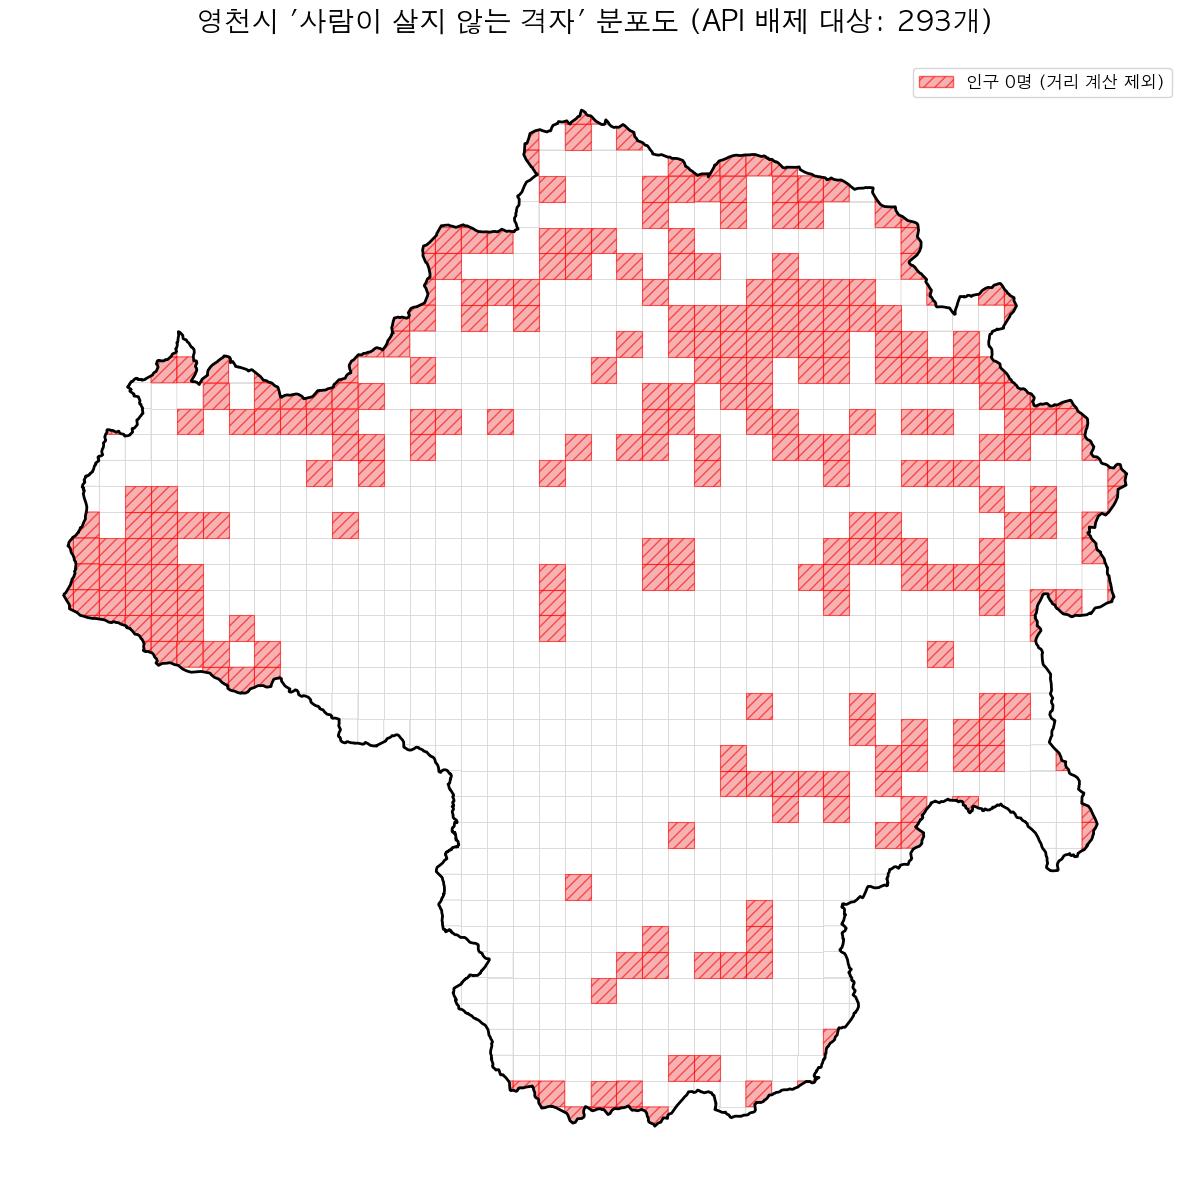

In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
import platform
import os

# 경고창 무시 및 한글 폰트 설정
warnings.filterwarnings('ignore')
system_os = platform.system()
if system_os == 'Darwin': plt.rcParams['font.family'] = 'AppleGothic'
elif system_os == 'Windows': plt.rcParams['font.family'] = 'Malgun Gothic'
else: plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================
# 🚨 [세팅값] 데이터 경로 설정 (현재 작업 폴더 기준)
# ==============================================================
SHP_PATH = 'grid_마마_1K.shp'
BORDER_PATH = 'bnd_sigungu_37070_2025_2Q.shp'
# 🌟 전체 인구가 들어있는 원본 파일 (폴더에 업로드되어 있어야 합니다)
POP_ALL_PATH = '2024년_인구_마마_1K.csv' 
# 🌟 새롭게 저장될 필터링 완료 격자 파일명
OUTPUT_CSV_PATH = 'step1_final_yeongcheon_filtered.csv'

# ==============================================================
print("🔄 [1/3] 지도 경계 및 격자판 세팅")
# ==============================================================
try:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')

sigungu_map = sigungu_map.to_crs(epsg=5179)
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].copy()
if len(yeongcheon_border) == 0: yeongcheon_border = sigungu_map.copy()

try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
grid_col = yeongcheon_grid.columns[0]
yeongcheon_grid[grid_col] = yeongcheon_grid[grid_col].astype(str).str.strip()


# ==============================================================
print("👥 [2/3] 전체 인구 데이터 결합 및 '빈 격자' 필터링")
# ==============================================================
if not os.path.exists(POP_ALL_PATH):
    print(f"❌ '{POP_ALL_PATH}' 파일을 찾을 수 없습니다. 현재 폴더에 파일을 업로드해주세요.")
else:
    # 1. 헤더 없이 데이터만 있는 CSV 구조에 맞춰 불러오기
    try:
        df_pop_all = pd.read_csv(POP_ALL_PATH, header=None, names=['year', 'grid_id', 'code', 'count'], encoding='utf-8')
    except:
        df_pop_all = pd.read_csv(POP_ALL_PATH, header=None, names=['year', 'grid_id', 'code', 'count'], encoding='cp949')

    # 2. 전체 인구수 코드('to_in_001')만 추출
    df_total_pop = df_pop_all[df_pop_all['code'] == 'to_in_001'].copy()
    df_total_pop['grid_id'] = df_total_pop['grid_id'].astype(str).str.strip()

    # 3. 지도 격자에 인구수 결합 (데이터가 없는 격자는 결측치 NaN 생성됨)
    final_map = yeongcheon_grid.merge(df_total_pop[['grid_id', 'count']], left_on=grid_col, right_on='grid_id', how='left')

    # 4. 분석 핵심 로직: 인구수가 0이거나 NaN인 곳을 True(배제 대상)로 마스킹
    # (count가 NaN이거나 0 이하인 경우를 모두 '사람이 없는 곳'으로 취급)
    final_map['is_empty'] = final_map['count'].isna() | (final_map['count'] <= 0)

    total_grids = len(final_map)
    empty_grids = final_map['is_empty'].sum()
    inhabited_grids = total_grids - empty_grids

    print(f"\n✅ 영천시 총 격자 수: {total_grids}개")
    print(f"👉 제외할 '빈 격자(인구 0명)': {empty_grids}개 (전체의 {empty_grids/total_grids*100:.1f}%)")
    print(f"👉 실제 분석(API 호출) 대상: {inhabited_grids}개")

    # ==============================================================
    # 🌟 [추가됨] 유효 격자 데이터만 추출하여 CSV로 저장
    # ==============================================================
    # is_empty가 False인 곳(사람이 사는 곳)만 추출
    valid_grids = final_map[~final_map['is_empty']].copy()
    
    # 불필요한 공간 데이터(geometry) 제외하고 필요한 컬럼만 정리해서 저장
    # grid_col은 격자코드 이름 ('GRID_CD' 등)
    valid_csv_df = valid_grids[[grid_col, 'count']].rename(columns={grid_col: '격자코드', 'count': '총인구수'})
    valid_csv_df.to_csv(OUTPUT_CSV_PATH, index=False, encoding='utf-8-sig')
    print(f"💾 유효 격자 데이터가 '{OUTPUT_CSV_PATH}'로 저장되었습니다!")


    # ==============================================================
    print("✨ [3/3] 제외 대상(빈 격자) 시각화")
    # ==============================================================
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))

    # 1. 기본 영천시 배경 (사람이 사는 곳 = 하얀색)
    final_map[~final_map['is_empty']].plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5)

    # 2. 🚨 배제 대상 빈 격자 칠하기 (붉은색 빗금 패턴)
    final_map[final_map['is_empty']].plot(ax=ax, color='lightcoral', edgecolor='red', linewidth=0.8, alpha=0.6, hatch='///', label='인구 0명 (API 제외 대상)')

    # 3. 영천시 외곽선 강조
    yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2)

    ax.set_title(f"영천시 '사람이 살지 않는 격자' 분포도 (API 배제 대상: {empty_grids}개)", fontsize=20, fontweight='bold', pad=20)
    ax.axis('off')

    # 범례 추가를 위한 꼼수 (Hatch 패턴 범례)
    import matplotlib.patches as mpatches
    red_patch = mpatches.Patch(facecolor='lightcoral', edgecolor='red', hatch='///', alpha=0.6, label='인구 0명 (거리 계산 제외)')
    ax.legend(handles=[red_patch], fontsize=12, loc='upper right')

    plt.tight_layout()
    plt.show()

## ✅ Step1. 각 격자별 모든 의료기관(보건소 + 병원) 까지 거리 top3(유클리드) & 정렬 산출

In [39]:
import pandas as pd
import geopandas as gpd
import numpy as np
from scipy.spatial import cKDTree
import warnings

warnings.filterwarnings('ignore')

def find_euclidean_top3_candidates():
    # ==============================================================
    # 🚨 파일 경로 설정 (제공해주신 파일명 Verbatim 적용)
    # ==============================================================
    grid_csv = 'step1_final_yeongcheon_filtered.csv'
    grid_shp = 'grid_마마_1K.shp' # 격자의 위경도(중심점)를 얻기 위한 원본 SHP
    med_csv = '경상북도 영천시_의료기관 현황(공공데이터포털,26).csv'
    health_csv = '경상북도 영천시_보건지소및보건진료소현황(공공데이터포털,24).csv'
    
    output_file = 'step2_euclidean_top3_candidates.csv'

    # 안전한 CSV 로드 함수 (인코딩 자동 감지)
    def load_csv_safe(path):
        try: return pd.read_csv(path, encoding='utf-8')
        except: return pd.read_csv(path, encoding='cp949')

    try:
        print("1️⃣ [데이터 준비] 인구 데이터 및 의료기관 데이터 로드 중...")
        grid_df = load_csv_safe(grid_csv)
        id_col = '격자코드' if '격자코드' in grid_df.columns else grid_df.columns[0]

        med_df = load_csv_safe(med_csv)
        health_df = load_csv_safe(health_csv)

        # 병원 + 보건소 통합
        med_sub = med_df[['의료기관명', '경도', '위도']].rename(columns={'의료기관명': '기관명'})
        h_col = '명칭' if '명칭' in health_df.columns else '보건기관명'
        health_sub = health_df[[h_col, '경도', '위도']].rename(columns={h_col: '기관명'})
        all_med_df = pd.concat([med_sub, health_sub], ignore_index=True)

        print("2️⃣ [좌표계 변환] 정확한 유클리드 거리(m) 계산을 위한 EPSG:32652 투영...")
        # 의료기관 GDF 생성
        med_gdf = gpd.GeoDataFrame(
            all_med_df, geometry=gpd.points_from_xy(all_med_df['경도'], all_med_df['위도']), crs="EPSG:4326"
        ).to_crs("EPSG:32652")

        # 격자 GDF 생성 (인구가 있는 격자만 필터링)
        grid_shp_gdf = gpd.read_file(grid_shp).to_crs("EPSG:32652")
        grid_shp_gdf['GRID_CD'] = grid_shp_gdf[grid_shp_gdf.columns[0]].astype(str).str.strip()
        target_grids = grid_shp_gdf[grid_shp_gdf['GRID_CD'].isin(grid_df[id_col].astype(str))].copy()
        target_grids['centroid'] = target_grids.geometry.centroid

        print("3️⃣ [거리 계산] KDTree 알고리즘으로 각 격자별 최단거리 Top 3 고속 탐색 중...")
        # KDTree는 유클리드 거리를 가장 빠르게 찾아주는 수학적 트리 구조입니다.
        med_coords = np.array([(geom.x, geom.y) for geom in med_gdf.geometry])
        tree = cKDTree(med_coords)

        grid_coords = np.array([(geom.x, geom.y) for geom in target_grids['centroid']])
        # k=3을 통해 가장 가까운 3개의 인덱스와 거리를 동시에 반환
        distances, indices = tree.query(grid_coords, k=3)

        print("4️⃣ [결과 정리] 도출된 Top 3 데이터를 정리하고 병합합니다...")
        results = []
        for i, (idx, row) in enumerate(target_grids.iterrows()):
            grid_cd = row['GRID_CD']
            
            # 격자 중심점 원래 위경도로 복구 (나중에 Kakao API 쓸 때 필요함)
            pt_wgs = gpd.GeoSeries([row['centroid']], crs="EPSG:32652").to_crs("EPSG:4326").iloc[0]
            
            res_row = {'격자코드': grid_cd, '경도': pt_wgs.x, '위도': pt_wgs.y}

            # Top 3 의료기관 정보 매핑
            for rank in range(3):
                med_idx = indices[i][rank]
                dist_km = distances[i][rank] / 1000.0  # 미터를 킬로미터로 변환

                res_row[f'후보{rank+1}_의료기관'] = all_med_df.iloc[med_idx]['기관명']
                res_row[f'후보{rank+1}_거리_km'] = round(dist_km, 3)
                res_row[f'후보{rank+1}_경도'] = all_med_df.iloc[med_idx]['경도']
                res_row[f'후보{rank+1}_위도'] = all_med_df.iloc[med_idx]['위도']

            results.append(res_row)

        res_df = pd.DataFrame(results)

        # 원본 인구 데이터(grid_df)와 결합
        # '경도', '위도' 컬럼이 겹칠 수 있으므로 grid_df 쪽에 있으면 제외하고 병합
        cols_to_use = grid_df.columns.difference(['경도', '위도'])
        final_df = grid_df[cols_to_use].merge(res_df, left_on=id_col, right_on='격자코드', how='right')

        # 취약지(가장 먼 곳)부터 확인하기 위해 후보1 거리 기준 내림차순 정렬
        final_df = final_df.sort_values(by=['후보1_거리_km'], ascending=False)
        
        # 보기 좋게 컬럼 순서 재배치
        front_cols = ['격자코드', '경도', '위도']
        other_cols = [c for c in final_df.columns if c not in front_cols]
        final_df = final_df[front_cols + other_cols]

        # 저장
        final_df.to_csv(output_file, index=False, encoding='utf-8-sig')
        print(f"✅ 유클리드 기반 Top 3 산출 완료! 결과가 '{output_file}'에 저장되었습니다.")

        # 미리보기
        print("\n📊 [정렬 결과 상위 3개 데이터 (의료 취약지)]")
        display_cols = ['격자코드', '후보1_의료기관', '후보1_거리_km', '후보2_거리_km', '후보3_거리_km']
        print(final_df[display_cols].head(3))

    except Exception as e:
        print(f"❗ 오류 발생: {e}")

# 실행
find_euclidean_top3_candidates()

1️⃣ [데이터 준비] 인구 데이터 및 의료기관 데이터 로드 중...
2️⃣ [좌표계 변환] 정확한 유클리드 거리(m) 계산을 위한 EPSG:32652 투영...
3️⃣ [거리 계산] KDTree 알고리즘으로 각 격자별 최단거리 Top 3 고속 탐색 중...
4️⃣ [결과 정리] 도출된 Top 3 데이터를 정리하고 병합합니다...
✅ 유클리드 기반 Top 3 산출 완료! 결과가 'step2_euclidean_top3_candidates.csv'에 저장되었습니다.

📊 [정렬 결과 상위 3개 데이터 (의료 취약지)]
       격자코드 후보1_의료기관  후보1_거리_km  후보2_거리_km  후보3_거리_km
16   마마1277   청통보건지소      6.814      6.915      6.943
94   마마1989  안천보건진료소      6.231      6.473      6.851
678  마마4390  보현보건진료소      6.042      7.043      7.241


## ✅ Step2. top3 산출된 것들 kakao api로 check & 보건소, 거리 갱신

In [48]:
import pandas as pd
import requests
import time
import os
from tqdm import tqdm

# ==========================================
# 1. 환경 설정 및 제어 변수
# ==========================================
KAKAO_API_KEY = "0fb61afb3b0dc7903fc7eb8bc6972774"
INPUT_FILE = "step2_euclidean_top3_candidates.csv"
OUTPUT_FILE = "step3_kakao_time_based_final.csv"

# 🌟 [제어 변수] 한 번 실행 시 갱신할 격자 수 (이 값을 조절하여 끊어서 실행 가능)
BATCH_SIZE = 100

def get_kakao_route_info(s_lon, s_lat, e_lon, e_lat):
    """Kakao API를 호출하여 차량 이동 시간(분)과 주행 거리(km)를 반환합니다."""
    url = "https://apis-navi.kakaomobility.com/v1/directions"
    headers = {"Authorization": f"KakaoAK {KAKAO_API_KEY}"}
    params = {
        "origin": f"{s_lon},{s_lat}",
        "destination": f"{e_lon},{e_lat}",
        "priority": "RECOMMEND"
    }
    try:
        response = requests.get(url, headers=headers, params=params)
        if response.status_code == 200:
            summary = response.json()['routes'][0]['summary']
            # duration은 초(s), distance는 미터(m) 단위로 반환됨
            time_min = summary['duration'] / 60.0
            dist_km = summary['distance'] / 1000.0
            return round(time_min, 2), round(dist_km, 2)
        else:
            return float('inf'), float('inf') # API 에러 시 무한대 처리
    except Exception:
        return float('inf'), float('inf')

# ==========================================
# 2. 데이터 로드 및 세이브포인트 설정
# ==========================================
# 기존 작업 파일이 있으면 이어서 하고, 없으면 원본에서 시작
if os.path.exists(OUTPUT_FILE):
    df_final = pd.read_csv(OUTPUT_FILE)
    print(f"💾 기존 작업 파일('{OUTPUT_FILE}')을 불러와 이어서 시작합니다.")
else:
    df_final = pd.read_csv(INPUT_FILE)
    # 갱신을 위한 신규 컬럼 생성
    df_final['최종_선정_의료기관'] = ""
    df_final['최종_이동시간_분'] = 0.0
    df_final['최종_주행거리_km'] = 0.0
    df_final['API_검증상태'] = "대기중"
    print(f"🆕 새 검증 작업을 시작합니다. (입력: {INPUT_FILE})")

# ==========================================
# 3. 미처리 데이터 추출 및 API 검증 (이동시간 기준)
# ==========================================
# '대기중'인 데이터만 추출하여 BATCH_SIZE 만큼 잘라냄
unprocessed = df_final[df_final['API_검증상태'] == '대기중']
target_indices = unprocessed.index[:BATCH_SIZE]

if len(target_indices) == 0:
    print("🎉 모든 격자의 Kakao 이동 시간 검증이 완료되었습니다!")
else:
    print(f"🚀 총 {len(unprocessed)}개 남음. 이번 턴에 상위 {len(target_indices)}개 격자 검증 시작...")
    
    for idx in tqdm(target_indices, desc="Kakao API 이동시간 검증 중"):
        row = df_final.loc[idx]
        s_lon, s_lat = row['경도'], row['위도']
        
        # 3개 후보지에 대한 시간/거리 측정
        api_results = []
        for i in range(1, 4):
            e_name = row[f'후보{i}_의료기관']
            e_lon, e_lat = row[f'후보{i}_경도'], row[f'후보{i}_위도']
            
            # 결측치 방어 로직
            if pd.isna(e_name): continue
                
            time_min, dist_km = get_kakao_route_info(s_lon, s_lat, e_lon, e_lat)
            
            api_results.append({
                'name': e_name, 
                'time': time_min, 
                'dist': dist_km, 
                'rank': f'후보{i}'
            })
            time.sleep(0.1) # API 초당 호출 제한 방어
            
        if not api_results:
            df_final.at[idx, 'API_검증상태'] = "후보없음"
            continue

        # ------------------------------------------
        # 4. 시간(Time) 기준 최단 기관 선정 로직
        # ------------------------------------------
        # 🌟 핵심: 'time'(이동시간) 기준으로 오름차순 정렬하여 가장 빠른 곳 선정
        api_results.sort(key=lambda x: x['time'])
        best_choice = api_results[0]
        
        # 만약 API가 모두 실패하여 시간이 inf라면 에러 처리
        if best_choice['time'] == float('inf'):
            df_final.at[idx, 'API_검증상태'] = "API통신오류"
        else:
            # 최종 결과 기록
            df_final.at[idx, '최종_선정_의료기관'] = best_choice['name']
            df_final.at[idx, '최종_이동시간_분'] = best_choice['time']
            df_final.at[idx, '최종_주행거리_km'] = best_choice['dist']
            
            # 라벨링 기록 (직선거리 1위와 실제 시간 1위가 동일한지 여부)
            if best_choice['rank'] == '후보1':
                df_final.at[idx, 'API_검증상태'] = "완료 (유클리드 1위 일치)"
            else:
                df_final.at[idx, 'API_검증상태'] = f"완료 (시간순 역전: {best_choice['rank']} 선정)"

    # ==========================================
    # 5. 결과 저장 및 상태 요약
    # ==========================================
    df_final.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
    print(f"\n✅ {len(target_indices)}개 데이터 갱신 완료 및 저장 성공!")
    
    # 진행 상태 통계 보여주기
    print("\n📊 [현재까지의 검증 라벨 요약]")
    print(df_final['API_검증상태'].value_counts())

# 이번에 갱신된 결과 샘플 5개 슬쩍 확인
display_cols = ['격자코드', '후보1_의료기관', '최종_선정_의료기관', '최종_이동시간_분', 'API_검증상태']
display(df_final.loc[target_indices, display_cols].head())

💾 기존 작업 파일('step3_kakao_time_based_final.csv')을 불러와 이어서 시작합니다.
🚀 총 21개 남음. 이번 턴에 상위 21개 격자 검증 시작...


Kakao API 이동시간 검증 중: 100%|██████████| 21/21 [00:16<00:00,  1.27it/s]


✅ 21개 데이터 갱신 완료 및 저장 성공!

📊 [현재까지의 검증 라벨 요약]
API_검증상태
완료 (유클리드 1위 일치)        506
완료 (시간순 역전: 후보2 선정)    129
완료 (시간순 역전: 후보3 선정)     65
API통신오류                 21
Name: count, dtype: int64


,격자코드,후보1_의료기관,최종_선정_의료기관,최종_이동시간_분,API_검증상태
700,마마2585,화남보건지소,화남보건지소,2.25,완료 (유클리드 1위 일치)
701,마마3894,보현보건진료소,보현보건진료소,0.77,완료 (유클리드 1위 일치)
702,마마3669,북안동산의원,북안동산의원,1.50,완료 (유클리드 1위 일치)
703,마마3477,육군3사관학교의원,육군3사관학교의원,2.72,완료 (유클리드 1위 일치)
704,마마3177,아침을 여는 한의윈,영천 퍼스트 치과의원,1.95,완료 (시간순 역전: 후보2 선정)


## ✅ Step3. API 매칭 실패 21개 이상치 수정
### 예상 사유 : 격자 중심점이 하천이거나 논밭 혹은 산인 경우 -> 카카오 api가 출발지 매칭 실패
### 해결 방안 : 격자를 인근 도로로 매핑해서 api 매칭 시도

In [50]:
import pandas as pd
import requests
import time
import os
import osmnx as ox
import networkx as nx
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 환경 설정
# ==========================================
KAKAO_API_KEY = "0fb61afb3b0dc7903fc7eb8bc6972774"
INPUT_FILE = "step3_kakao_time_based_final.csv"  # 현재 오류/직선거리가 포함된 파일
OUTPUT_FILE = "step3_kakao_time_based_fixed_strict.csv" # 엄격하게 수정된 최종 파일

def get_kakao_route_info(s_lon, s_lat, e_lon, e_lat):
    """카카오 API 호출"""
    url = "https://apis-navi.kakaomobility.com/v1/directions"
    headers = {"Authorization": f"KakaoAK {KAKAO_API_KEY}"}
    params = {
        "origin": f"{s_lon},{s_lat}",
        "destination": f"{e_lon},{e_lat}",
        "priority": "RECOMMEND"
    }
    try:
        response = requests.get(url, headers=headers, params=params)
        res_json = response.json()
        
        if response.status_code == 200:
            summary = res_json['routes'][0]['summary']
            return round(summary['duration'] / 60.0, 2), round(summary['distance'] / 1000.0, 2), "성공"
        else:
            msg = res_json.get('error_msg', '경로탐색불가')
            return None, None, f"API에러({msg})"
    except Exception as e:
        return None, None, "통신장애"

# ==========================================
# 2. 데이터 로드 및 타겟 선정
# ==========================================
print(f"📂 데이터 로드 중: '{INPUT_FILE}'")
df_final = pd.read_csv(INPUT_FILE)

# 수정 대상: 대기중, 실패, 오류, 또는 이전에 '직선거리'로 어설프게 메워진 데이터 전부
target_mask = df_final['API_검증상태'].str.contains('오류|실패|대기중|후보없음|직선거리', na=False)
error_indices = df_final[target_mask].index

if len(error_indices) == 0:
    print("🎉 수정할 이상치 데이터가 없습니다.")
    df_final.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
else:
    print(f"🚨 총 {len(error_indices)}개의 이상치 격자 발견. '인접 도로 매핑' 복구 작업을 시작합니다!")
    
    # ==========================================
    # 3. OSMnx 도로망 로드 (인접 도로 찾기 용도)
    # ==========================================
    print("🛣️ 영천시 도로망 데이터를 불러오는 중... (최초 1회, 약 30초 소요)")
    G_wgs = ox.graph_from_place('Yeongcheon-si, Gyeongsangbuk-do, South Korea', network_type='drive')
    nodes_x = nx.get_node_attributes(G_wgs, 'x')
    nodes_y = nx.get_node_attributes(G_wgs, 'y')

    # ==========================================
    # 4. 이상치 집중 치료 (도로 매핑)
    # ==========================================
    for idx in tqdm(error_indices, desc="인접도로 매핑 및 카카오 재검증"):
        row = df_final.loc[idx]
        g_lon, g_lat = row['경도'], row['위도']
        
        # 🌟 핵심 로직: 허허벌판인 격자 중심점을 '가장 가까운 차도(Node)'로 끌어옵니다.
        nearest_node = ox.distance.nearest_nodes(G_wgs, g_lon, g_lat)
        snap_lon, snap_lat = nodes_x[nearest_node], nodes_y[nearest_node]
        
        api_results = []
        
        for i in range(1, 4):
            e_name = row[f'후보{i}_의료기관']
            e_lon, e_lat = row[f'후보{i}_경도'], row[f'후보{i}_위도']
            
            if pd.isna(e_name): continue
            
            # 원래 좌표(g_lon, g_lat)가 아닌, 차도 좌표(snap_lon, snap_lat)로 카카오 API 호출
            time_min, dist_km, status = get_kakao_route_info(snap_lon, snap_lat, e_lon, e_lat)
            
            if status == "성공":
                api_results.append({
                    'name': e_name, 
                    'time': time_min, 
                    'dist': dist_km, 
                    'rank': f'후보{i}'
                })
            time.sleep(0.05)

        # ------------------------------------------
        # 5. 엄격한 결과 판정 및 라벨링
        # ------------------------------------------
        if api_results:
            # 성공한 결과가 하나라도 있으면 시간순 정렬 후 최단 시간 선정
            api_results.sort(key=lambda x: x['time'])
            best = api_results[0]
            
            df_final.at[idx, '최종_선정_의료기관'] = best['name']
            df_final.at[idx, '최종_이동시간_분'] = best['time']
            df_final.at[idx, '최종_주행거리_km'] = best['dist']
            
            # 인접 도로로 이동해서 성공했음을 명시
            if best['rank'] == '후보1':
                df_final.at[idx, 'API_검증상태'] = "복구완료 (인접도로 매핑 / 1위 일치)"
            else:
                df_final.at[idx, 'API_검증상태'] = f"복구완료 (인접도로 매핑 / 시간역전: {best['rank']})"
        else:
            # 🌟 인접 도로로 끌어와도 실패하면, 가차 없이 '복구실패' 처리 (직선거리 안 씀)
            df_final.at[idx, '최종_선정_의료기관'] = "접근불가"
            df_final.at[idx, '최종_이동시간_분'] = 999.0
            df_final.at[idx, '최종_주행거리_km'] = 99.0
            df_final.at[idx, 'API_검증상태'] = "복구실패 (물리적 도로망 단절)"

    # ==========================================
    # 6. 최종 파일 저장
    # ==========================================
    df_final.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
    print(f"\n✅ 엄격한 기준의 이상치 갱신 완료! 결과가 '{OUTPUT_FILE}'에 저장되었습니다.")
    
    print("\n📊 [복구 후 라벨 요약]")
    print(df_final['API_검증상태'].value_counts())

📂 데이터 로드 중: 'step3_kakao_time_based_final.csv'
🚨 총 21개의 이상치 격자 발견. '인접 도로 매핑' 복구 작업을 시작합니다!
🛣️ 영천시 도로망 데이터를 불러오는 중... (최초 1회, 약 30초 소요)


인접도로 매핑 및 카카오 재검증: 100%|██████████| 21/21 [00:12<00:00,  1.67it/s]


✅ 엄격한 기준의 이상치 갱신 완료! 결과가 'step3_kakao_time_based_fixed_strict.csv'에 저장되었습니다.

📊 [복구 후 라벨 요약]
API_검증상태
완료 (유클리드 1위 일치)               506
완료 (시간순 역전: 후보2 선정)           129
완료 (시간순 역전: 후보3 선정)            65
복구완료 (인접도로 매핑 / 1위 일치)         13
복구완료 (인접도로 매핑 / 시간역전: 후보3)      6
복구완료 (인접도로 매핑 / 시간역전: 후보2)      2
Name: count, dtype: int64


## ✅ Step4. 정렬 후 최종 결과

In [51]:
import pandas as pd

# ==========================================
# 1. 파일 경로 설정
# ==========================================
INPUT_FILE = "step3_kakao_time_based_fixed_strict.csv"
OUTPUT_FILE = "step4_final_medical_vulnerability.csv" # 깔끔한 최종 결과물 파일명

try:
    print(f"📂 데이터 로드 중: '{INPUT_FILE}'")
    df = pd.read_csv(INPUT_FILE)

    # ==========================================
    # 2. 필수 컬럼 추출 (유연성 확보)
    # ==========================================
    # 성현님이 요청하신 핵심 컬럼 리스트
    target_cols = [
        '격자코드', '경도', '위도', '총인구수', 
        '최종_선정_의료기관', '최종_이동시간_분', '최종_주행거리_km', 'API_검증상태'
    ]
    
    # 💡 팁: 국토부 인구 격자 데이터 원본에 따라 '총인구수'가 '인구수', 'val', '총인구' 등으로 
    # 되어 있을 수 있으므로, 실제 존재하는 컬럼만 안전하게 가져옵니다.
    available_cols = [col for col in target_cols if col in df.columns]
    missing_cols = [col for col in target_cols if col not in df.columns]
    
    if missing_cols:
        print(f"⚠️ 알림: 원본 데이터에서 다음 컬럼을 찾지 못했습니다 -> {missing_cols}")
        print("    (만약 인구수 컬럼명이 다르다면 원본 파일의 컬럼명을 확인해 주세요.)")

    df_subset = df[available_cols]

    # ==========================================
    # 3. 데이터 정렬 (의료 취약지 우선)
    # ==========================================
    # 시간이 가장 오래 걸리는 격자(최대 취약지)가 1등으로 오도록 내림차순(False) 정렬합니다.
    df_sorted = df_subset.sort_values(by='최종_이동시간_분', ascending=False)

    # ==========================================
    # 4. 최종 저장 및 결과 미리보기
    # ==========================================
    df_sorted.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
    
    print(f"\n✅ 데이터 추출 및 정렬 완료! 최종 결과가 '{OUTPUT_FILE}'에 저장되었습니다.")
    
    print("\n📊 [최종 결과 - 영천시 의료 취약 격자 Top 5]")
    # 주피터 노트북 환경이라면 display() 사용, 일반 터미널이면 print() 사용
    try:
        display(df_sorted.head())
    except:
        print(df_sorted.head())

except FileNotFoundError:
    print(f"❌ 오류: '{INPUT_FILE}' 파일을 찾을 수 없습니다. 파일명을 다시 확인해 주세요.")
except Exception as e:
    print(f"❌ 분석 중 오류 발생: {e}")

📂 데이터 로드 중: 'step3_kakao_time_based_fixed_strict.csv'

✅ 데이터 추출 및 정렬 완료! 최종 결과가 'step4_final_medical_vulnerability.csv'에 저장되었습니다.

📊 [최종 결과 - 영천시 의료 취약 격자 Top 5]


,격자코드,경도,위도,총인구수,최종_선정_의료기관,최종_이동시간_분,최종_주행거리_km,API_검증상태
169,마마3083,128.948624,36.039632,8,임고보건지소,55.17,65.58,완료 (유클리드 1위 일치)
67,마마3697,129.017632,36.164986,5,보현보건진료소,47.03,24.11,완료 (유클리드 1위 일치)
61,마마3260,128.966983,35.832062,28,명주보건진료소,43.67,25.02,완료 (시간순 역전: 후보2 선정)
450,마마4183,129.070691,36.038095,33,사리보건진료소,35.62,37.88,완료 (유클리드 1위 일치)
241,마마4283,129.081787,36.037949,18,사리보건진료소,35.10,37.03,완료 (유클리드 1위 일치)


## ✅ Step5. 의료기관 도달 시간기준 히트맵 시각화

1️⃣ [데이터 로드] 최종 결과 및 격자 공간 데이터를 불러옵니다...
2️⃣ [지도 생성] 영천시 경계 데이터를 다운로드 중입니다...
3️⃣ [시각화] 히트맵 렌더링 중... (잠시만 기다려주세요)


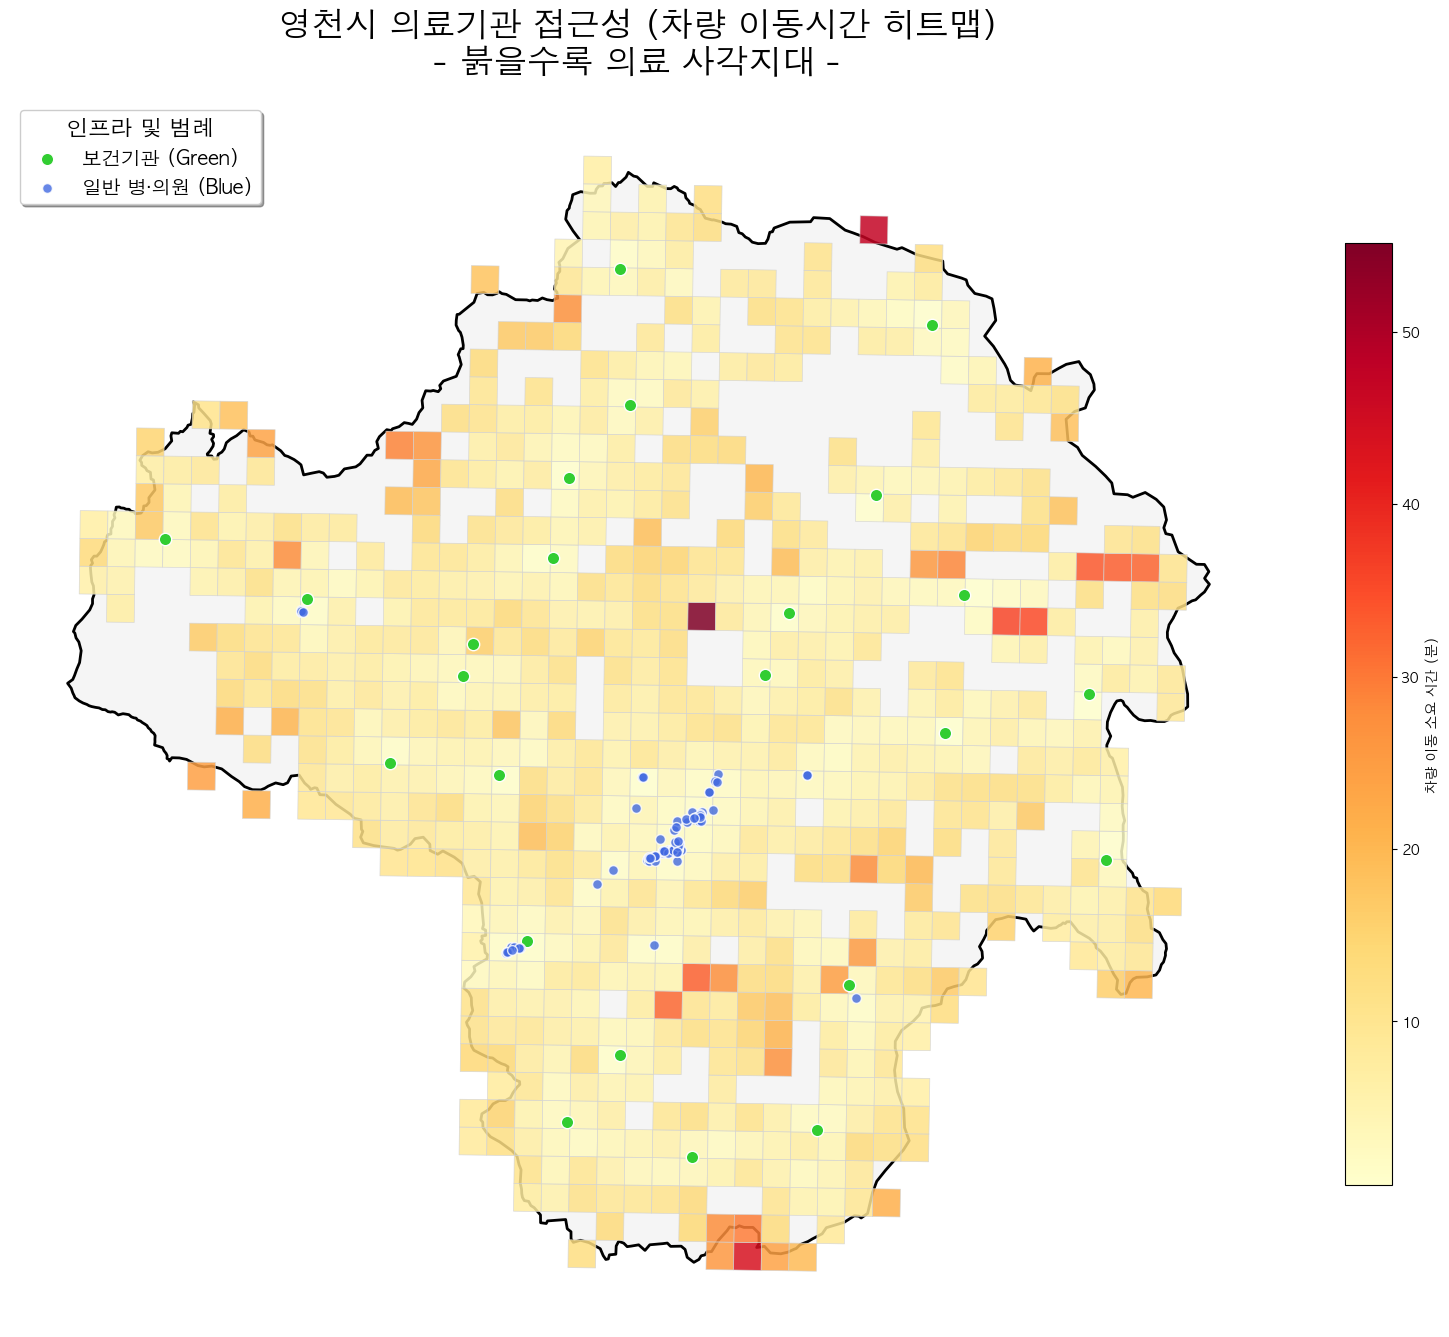

✅ 시각화가 완료되었습니다!


In [54]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import platform
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 환경 및 폰트 설정
# ==========================================
system_os = platform.system()
if system_os == 'Darwin': plt.rcParams['font.family'] = 'AppleGothic'
elif system_os == 'Windows': plt.rcParams['font.family'] = 'Malgun Gothic'
else: plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. 파일 경로 설정 (성현님이 올려주신 파일명 반영)
# ==========================================
RESULT_FILE = "step4_final_medical_vulnerability.csv"
SHP_FILE = "grid_마마_1K.shp"
MED_CSV_FILE = "경상북도 영천시_의료기관 현황(공공데이터포털,26).csv"
HEALTH_CSV_FILE = "경상북도 영천시_보건지소및보건진료소현황(공공데이터포털,24).csv"

def visualize_vulnerability_heatmap():
    print("1️⃣ [데이터 로드] 최종 결과 및 격자 공간 데이터를 불러옵니다...")
    
    try:
        df_res = pd.read_csv(RESULT_FILE)
    except FileNotFoundError:
        print(f"❌ '{RESULT_FILE}' 파일을 찾을 수 없습니다.")
        return

    # 1km 격자 SHP 파일 로드 및 좌표계 변환
    try:
        grid_gdf = gpd.read_file(SHP_FILE).to_crs("EPSG:4326")
        # 컬럼명이 다를 수 있으므로 첫 번째 컬럼을 격자코드로 강제 인식
        grid_gdf['GRID_CD'] = grid_gdf[grid_gdf.columns[0]].astype(str).str.strip()
    except Exception as e:
        print(f"❌ SHP 파일 로드 오류: {e}")
        return
        
    # 데이터 병합 (지도 데이터 + 이동시간 데이터)
    merged_gdf = grid_gdf.merge(df_res, left_on='GRID_CD', right_on='격자코드', how='inner')

    def load_safe(p):
        try: return pd.read_csv(p, encoding='utf-8')
        except: return pd.read_csv(p, encoding='cp949')

    try:
        df_med = load_safe(MED_CSV_FILE)
        df_health = load_safe(HEALTH_CSV_FILE)
    except FileNotFoundError:
        print("❌ 의료기관 또는 보건지소 원본 CSV 파일을 찾을 수 없습니다.")
        return

    print("2️⃣ [지도 생성] 영천시 경계 데이터를 다운로드 중입니다...")
    try:
        yeongcheon_boundary = ox.geocode_to_gdf('Yeongcheon-si, Gyeongsangbuk-do, South Korea')
    except Exception as e:
        print(f"❌ 영천시 경계 다운로드 오류: {e}")
        return

    print("3️⃣ [시각화] 히트맵 렌더링 중... (잠시만 기다려주세요)")
    fig, ax = plt.subplots(figsize=(16, 16))

    # (1) 배경: 영천시 경계선
    yeongcheon_boundary.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=2, zorder=1)

    # (2) 히트맵 렌더링 (차량이 못 가는 '999분' 데이터 분리)
    valid_grids = merged_gdf[merged_gdf['최종_이동시간_분'] < 900]
    failed_grids = merged_gdf[merged_gdf['최종_이동시간_분'] >= 900]

    if not valid_grids.empty:
        valid_grids.plot(
            column='최종_이동시간_분', 
            cmap='YlOrRd',  # 노란색 -> 주황색 -> 빨간색
            ax=ax, 
            alpha=0.85,
            edgecolor='lightgray', 
            linewidth=0.5,
            legend=True, 
            legend_kwds={'label': '차량 이동 소요 시간 (분)', 'shrink': 0.6, 'orientation': 'vertical'},
            zorder=2
        )

    # (3) 예외 격자 렌더링 (차량 진입 불가 극오지)
    if not failed_grids.empty:
        failed_grids.plot(ax=ax, color='dimgray', alpha=0.7, hatch='///', edgecolor='black', zorder=3)

    # (4) 인프라 마커 표시
    ax.scatter(df_health['경도'], df_health['위도'], c='limegreen', s=80, label='보건기관 (Green)', edgecolors='white', linewidth=1, zorder=4)
    ax.scatter(df_med['경도'], df_med['위도'], c='royalblue', s=50, label='일반 병·의원 (Blue)', edgecolors='white', linewidth=1, alpha=0.8, zorder=4)

    # (5) 디테일 및 타이틀 설정
    ax.set_axis_off()
    plt.title("영천시 의료기관 접근성 (차량 이동시간 히트맵)\n- 붉을수록 의료 사각지대 -", fontsize=24, fontweight='bold', pad=20)
    
    # 범례 깔끔하게 모으기
    handles, labels = ax.get_legend_handles_labels()
    import matplotlib.patches as mpatches
    if not failed_grids.empty:
        failed_patch = mpatches.Patch(facecolor='dimgray', hatch='///', label='도로 접근 불가 격자', alpha=0.7)
        handles.append(failed_patch)
        labels.append('도로 접근 불가 격자')
        
    ax.legend(handles, labels, loc='upper left', fontsize=14, frameon=True, shadow=True, title="인프라 및 범례", title_fontsize=16)

    plt.tight_layout()
    plt.show()
    print("✅ 시각화가 완료되었습니다!")

# 실행
visualize_vulnerability_heatmap()

## ** 시각화 도로망 추가 버전 **

1️⃣ [데이터 로드] 최종 결과 및 격자, 의료기관 데이터를 불러옵니다...
2️⃣ [공간 데이터 구축] 영천시 경계 및 🛣️ 자동차 도로망 다운로드 중... (약 1~2분 소요)
3️⃣ [시각화] 히트맵 및 도로망 오버레이 렌더링 중...


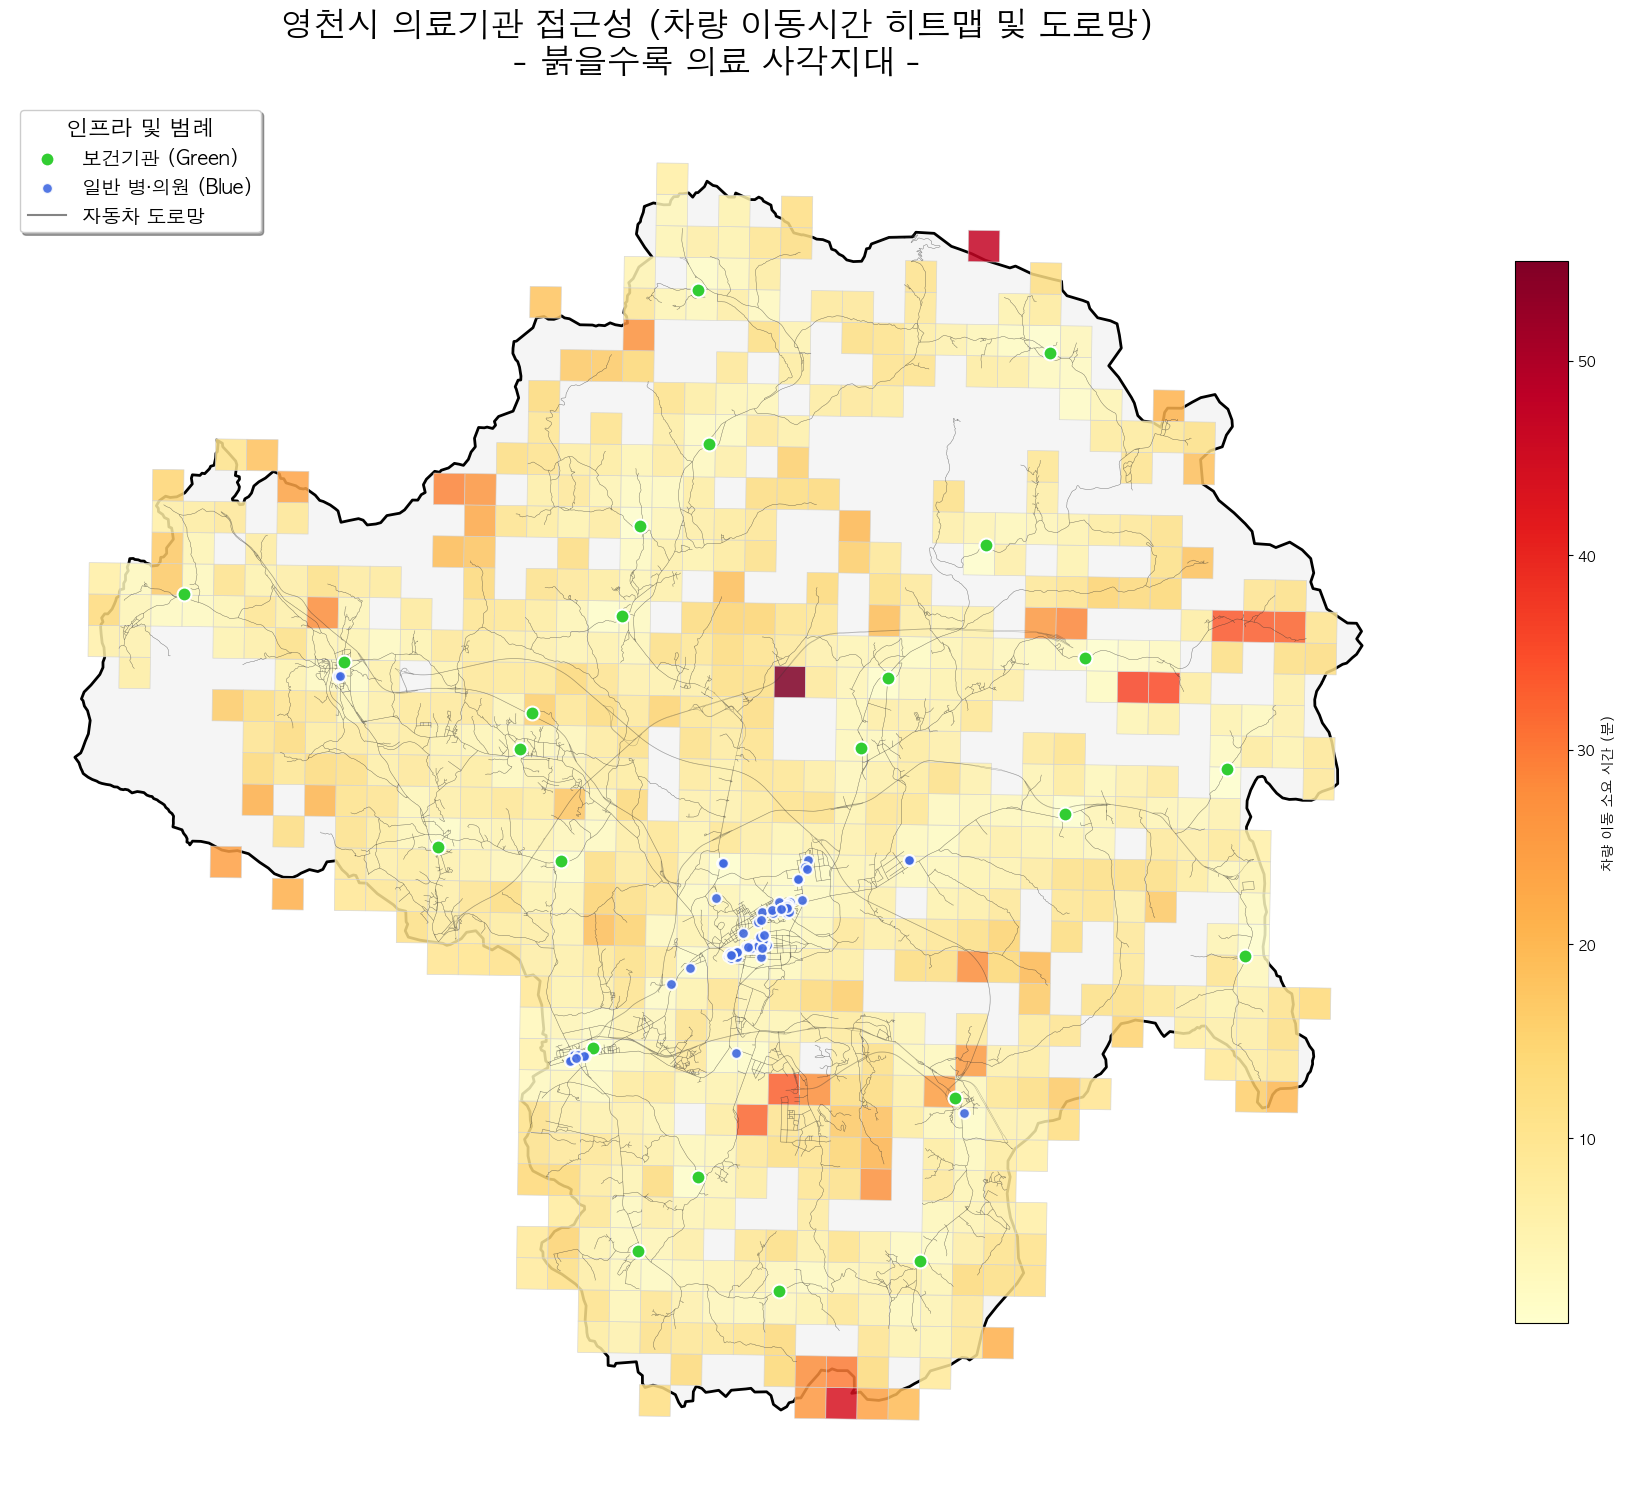

✅ 시각화가 완료되었습니다!


In [56]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import platform
import warnings
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# ==========================================
# 1. 환경 및 폰트 설정
# ==========================================
system_os = platform.system()
if system_os == 'Darwin': plt.rcParams['font.family'] = 'AppleGothic'
elif system_os == 'Windows': plt.rcParams['font.family'] = 'Malgun Gothic'
else: plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. 파일 경로 설정
# ==========================================
RESULT_FILE = "step4_final_medical_vulnerability.csv"
SHP_FILE = "grid_마마_1K.shp"
MED_CSV_FILE = "경상북도 영천시_의료기관 현황(공공데이터포털,26).csv"
HEALTH_CSV_FILE = "경상북도 영천시_보건지소및보건진료소현황(공공데이터포털,24).csv"

def visualize_heatmap_with_roads():
    print("1️⃣ [데이터 로드] 최종 결과 및 격자, 의료기관 데이터를 불러옵니다...")
    
    try:
        df_res = pd.read_csv(RESULT_FILE)
    except FileNotFoundError:
        print(f"❌ '{RESULT_FILE}' 파일을 찾을 수 없습니다.")
        return

    try:
        grid_gdf = gpd.read_file(SHP_FILE).to_crs("EPSG:4326")
        grid_gdf['GRID_CD'] = grid_gdf[grid_gdf.columns[0]].astype(str).str.strip()
    except Exception as e:
        print(f"❌ SHP 파일 로드 오류: {e}")
        return
        
    merged_gdf = grid_gdf.merge(df_res, left_on='GRID_CD', right_on='격자코드', how='inner')

    def load_safe(p):
        try: return pd.read_csv(p, encoding='utf-8')
        except: return pd.read_csv(p, encoding='cp949')

    df_med = load_safe(MED_CSV_FILE)
    df_health = load_safe(HEALTH_CSV_FILE)

    print("2️⃣ [공간 데이터 구축] 영천시 경계 및 🛣️ 자동차 도로망 다운로드 중... (약 1~2분 소요)")
    try:
        # 영천시 외곽선
        yeongcheon_boundary = ox.geocode_to_gdf('Yeongcheon-si, Gyeongsangbuk-do, South Korea')
        # 영천시 도로망 (네트워크)
        G_wgs = ox.graph_from_place('Yeongcheon-si, Gyeongsangbuk-do, South Korea', network_type='drive')
        # 도로망을 시각화하기 편한 GeoDataFrame(LineString)으로 변환
        edges = ox.graph_to_gdfs(G_wgs, nodes=False)
    except Exception as e:
        print(f"❌ 도로망/경계 다운로드 오류: {e}")
        return

    print("3️⃣ [시각화] 히트맵 및 도로망 오버레이 렌더링 중...")
    fig, ax = plt.subplots(figsize=(18, 18))

    # (1) 배경: 영천시 경계선 (zorder=1)
    yeongcheon_boundary.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=2, zorder=1)

    # (2) 히트맵 렌더링 (zorder=2)
    valid_grids = merged_gdf[merged_gdf['최종_이동시간_분'] < 900]
    failed_grids = merged_gdf[merged_gdf['최종_이동시간_분'] >= 900]

    if not valid_grids.empty:
        valid_grids.plot(
            column='최종_이동시간_분', 
            cmap='YlOrRd', 
            ax=ax, 
            alpha=0.85,
            edgecolor='lightgray', 
            linewidth=0.5,
            legend=True, 
            legend_kwds={'label': '차량 이동 소요 시간 (분)', 'shrink': 0.6, 'orientation': 'vertical'},
            zorder=2
        )

    # (3) 예외 격자 렌더링 (차량 진입 불가 극오지) (zorder=3)
    if not failed_grids.empty:
        failed_grids.plot(ax=ax, color='dimgray', alpha=0.7, hatch='///', edgecolor='black', zorder=3)

    # (4) 🌟 도로망 오버레이 (zorder=4) - 히트맵 위에 반투명하게 얹기
    edges.plot(ax=ax, color='#333333', linewidth=0.3, alpha=0.4, zorder=4)

    # (5) 인프라 마커 표시 (zorder=5)
    ax.scatter(df_health['경도'], df_health['위도'], c='limegreen', s=100, label='보건기관 (Green)', edgecolors='white', linewidth=1.5, zorder=5)
    ax.scatter(df_med['경도'], df_med['위도'], c='royalblue', s=60, label='일반 병·의원 (Blue)', edgecolors='white', linewidth=1.5, alpha=0.9, zorder=5)

    # (6) 디테일 및 타이틀 설정
    ax.set_axis_off()
    plt.title("영천시 의료기관 접근성 (차량 이동시간 히트맵 및 도로망)\n- 붉을수록 의료 사각지대 -", fontsize=24, fontweight='bold', pad=20)
    
    # 범례 커스텀 생성
    handles, labels = ax.get_legend_handles_labels()
    
    # 도로망 범례 추가
    road_line = Line2D([0], [0], color='#333333', lw=1.5, alpha=0.6, label='자동차 도로망')
    handles.append(road_line)
    labels.append('자동차 도로망')
    
    # 접근 불가 격자 범례 추가
    if not failed_grids.empty:
        failed_patch = mpatches.Patch(facecolor='dimgray', hatch='///', label='도로 접근 불가 격자', alpha=0.7)
        handles.append(failed_patch)
        labels.append('도로 접근 불가 격자')
        
    ax.legend(handles, labels, loc='upper left', fontsize=14, frameon=True, shadow=True, title="인프라 및 범례", title_fontsize=16)

    plt.tight_layout()
    plt.show()
    print("✅ 시각화가 완료되었습니다!")

# 실행
visualize_heatmap_with_roads()

## ** 가까운 의료기관 카테고리별 갯수, 퍼센트 계산 **

In [60]:
import pandas as pd

def analyze_medical_facilities_detailed():
    # 파일 경로 설정 (성현님이 지정하신 파일명)
    input_file = "step4_final_medical_vulnerability.csv"
    
    try:
        # 데이터 로드
        df = pd.read_csv(input_file)
        
        # '접근불가' 등 유효하지 않은 데이터는 분석에서 제외
        valid_df = df[df['최종_선정_의료기관'] != '접근불가'].dropna(subset=['최종_선정_의료기관'])
        total_valid = len(valid_df)
        
        print(f"📊 총 유효 분석 대상 격자 수: {total_valid}개 (접근불가 제외)\n")
        
        # 1. 더욱 세분화된 의료기관 분류 함수 정의
        def categorize_facility_detailed(name):
            name_str = str(name)
            if '보건' in name_str:
                return '보건소(보건지소/진료소)'
            elif '요양병원' in name_str:
                return '요양병원'
            elif '종합병원' in name_str:
                return '종합병원'
            elif '한의원' in name_str or '한방' in name_str:
                return '한의원'
            elif '치과' in name_str:
                return '치과'
            elif name_str.endswith('의원'):
                return '일반의원'
            else:
                return '기타 병원(일반병원 등)'

        # 분류 결과 새로운 컬럼에 저장
        valid_df['기관분류'] = valid_df['최종_선정_의료기관'].apply(categorize_facility_detailed)
        
        # 2. 개수 및 비율 계산
        category_counts = valid_df['기관분류'].value_counts()
        category_ratios = (category_counts / total_valid * 100).round(2)
        
        # 결과 데이터프레임 생성 및 정렬
        summary_df = pd.DataFrame({
            '격자 개수': category_counts,
            '비율(%)': category_ratios
        })
        
        print("📈 [가장 가까운 의료기관 유형별 격자 분포]")
        print("-" * 50)
        print(summary_df)
        print("-" * 50 + "\n")
        
        # 3. 타겟 시설(치과, 한의원, 요양병원) 해당 격자 추출
        dental_clinics = valid_df[valid_df['기관분류'] == '치과']['격자코드'].tolist()
        oriental_clinics = valid_df[valid_df['기관분류'] == '한의원']['격자코드'].tolist()
        nursing_hospitals = valid_df[valid_df['기관분류'] == '요양병원']['격자코드'].tolist()
        
        print(f"🦷 [치과]가 가장 가까운 격자 목록 (총 {len(dental_clinics)}개):")
        if dental_clinics:
            print(", ".join(dental_clinics))
        else:
            print("해당하는 격자가 없습니다.")
            
        print(f"\n🌿 [한의원]이 가장 가까운 격자 목록 (총 {len(oriental_clinics)}개):")
        if oriental_clinics:
            print(", ".join(oriental_clinics))
        else:
            print("해당하는 격자가 없습니다.")
            
        print(f"\n🏥 [요양병원]이 가장 가까운 격자 목록 (총 {len(nursing_hospitals)}개):")
        if nursing_hospitals:
            print(", ".join(nursing_hospitals))
        else:
            print("해당하는 격자가 없습니다.")
            
    except FileNotFoundError:
        print(f"❌ 오류: '{input_file}' 파일을 찾을 수 없습니다. 파일명을 다시 한번 확인해주세요.")
    except Exception as e:
        print(f"❌ 분석 중 오류 발생: {e}")

# 함수 실행
analyze_medical_facilities_detailed()

📊 총 유효 분석 대상 격자 수: 721개 (접근불가 제외)

📈 [가장 가까운 의료기관 유형별 격자 분포]
--------------------------------------------------
               격자 개수  비율(%)
기관분류                       
보건소(보건지소/진료소)    528  73.23
일반의원             102  14.15
기타 병원(일반병원 등)     29   4.02
요양병원              24   3.33
한의원               22   3.05
치과                16   2.22
--------------------------------------------------

🦷 [치과]가 가장 가까운 격자 목록 (총 16개):
마마3774, 마마3975, 마마3977, 마마3179, 마마3079, 마마3976, 마마2468, 마마3877, 마마3778, 마마3278, 마마2469, 마마3777, 마마3277, 마마2976, 마마3177, 마마2371

🌿 [한의원]이 가장 가까운 격자 목록 (총 22개):
마마3273, 마마2575, 마마3173, 마마2576, 마마2873, 마마3073, 마마2676, 마마2570, 마마3174, 마마2569, 마마2572, 마마2973, 마마2874, 마마2876, 마마2875, 마마3074, 마마2776, 마마2470, 마마3075, 마마2975, 마마2974, 마마1683

🏥 [요양병원]이 가장 가까운 격자 목록 (총 24개):
마마2476, 마마2781, 마마2981, 마마2573, 마마2677, 마마2980, 마마2878, 마마2782, 마마2678, 마마2882, 마마2780, 마마2979, 마마2881, 마마2978, 마마2880, 마마2779, 마마2879, 마마2778, 마마2977, 마마2777, 마마2672, 마마2675, 마마2673, 마마2877


## ✅ Step6. 이상치 처리(소요 시간이 주변에 비해 극도로 높은 격자들)

### 해결 방안 1 : 스무딩 기법으로 주변 격자들의 평균으로 대체
### 해결 방안 2 : 망거리로 대체
### 결론 -> 스무딩 기법으로 대체해보고, 시각화 해보고 여전히 이상한 애들은 망거리로 수작업 체크

### ✅ Step6-1. 이상치인 격자들 추출 (둘러싸고있는 격자들 대비 1.5배 이상인 애들)

In [62]:
import pandas as pd
import geopandas as gpd
import numpy as np

def find_spatial_travel_outliers():
    # 1. 파일 경로 설정
    RESULT_FILE = "step4_final_medical_vulnerability.csv"
    SHP_FILE = "grid_마마_1K.shp"

    try:
        # 데이터 로드
        df_res = pd.read_csv(RESULT_FILE)
        grid_gdf = gpd.read_file(SHP_FILE).to_crs("EPSG:4326")
        grid_gdf['GRID_CD'] = grid_gdf[grid_gdf.columns[0]].astype(str).str.strip()
        
        # 지도와 분석 결과 병합
        merged_gdf = grid_gdf.merge(df_res, left_on='GRID_CD', right_on='격자코드', how='inner')
        
        # 999분(접근불가) 격자는 주변 평균을 왜곡하므로 제외하고 분석
        valid_gdf = merged_gdf[merged_gdf['최종_이동시간_분'] < 900].copy()
        
        outlier_list = []
        
        print("🔍 공간적 이상치 분석 중... (격자별 주변 환경 비교)")
        
        for idx, row in valid_gdf.iterrows():
            # [핵심] 현재 격자와 경계가 닿아있는 인접 격자(8방향) 추출
            neighbors = valid_gdf[valid_gdf.geometry.touches(row.geometry)]
            
            if len(neighbors) >= 3: # 주변에 최소 3개 이상의 데이터가 있을 때만 신뢰
                n_mean = neighbors['최종_이동시간_분'].mean()
                my_time = row['최종_이동시간_분']
                
                # 🌟 이상치 판단 기준: 주변 평균보다 1.5배 이상 느리고, 10분 이상 차이 날 때
                if (my_time > n_mean * 1.5) and (my_time - n_mean > 10):
                    outlier_list.append({
                        '격자코드': row['격자코드'],
                        '선정기관': row['최종_선정_의료기관'],
                        '내_시간(분)': round(my_time, 2),
                        '주변_평균(분)': round(n_mean, 2),
                        '추가_소요(분)': round(my_time - n_mean, 2),
                        '배수': round(my_time / n_mean, 2)
                    })

        outlier_df = pd.DataFrame(outlier_list).sort_values(by='추가_소요(분)', ascending=False)

        if not outlier_df.empty:
            print(f"\n🚨 총 {len(outlier_df)}개의 공간적 이상치 격자를 발견했습니다.")
            print("-" * 70)
            print(outlier_df.head(15)) # 상위 15개 출력
            print("-" * 70)
            outlier_df.to_csv("spatial_outliers_report.csv", index=False, encoding='utf-8-sig')
            print("💾 상세 리스트가 'spatial_outliers_report.csv'로 저장되었습니다.")
        else:
            print("\n✅ 주변 대비 비정상적으로 의료 접근성이 낮은 격자가 없습니다.")

    except Exception as e:
        print(f"❌ 분석 실패: {e}")

# 실행
find_spatial_travel_outliers()

🔍 공간적 이상치 분석 중... (격자별 주변 환경 비교)

🚨 총 22개의 공간적 이상치 격자를 발견했습니다.
----------------------------------------------------------------------
      격자코드             선정기관  내_시간(분)  주변_평균(분)  추가_소요(분)    배수
6   마마3083           임고보건지소    55.17      9.53     45.64  5.79
16  마마4183          사리보건진료소    35.62      7.63     27.99  4.67
17  마마4283          사리보건진료소    35.10      9.73     25.37  3.61
4   마마2969  의료법인동승의료재단 동승병원    31.85     10.62     21.22  3.00
1   마마1585             신령의원    27.62      7.12     20.50  3.88
5   마마3070  의료법인동승의료재단 동승병원    32.75     12.89     19.86  2.54
8   마마3260          명주보건진료소    43.67     23.99     19.68  1.82
15  마마3985           고경보건지소    28.33      9.53     18.80  2.97
19  마마4485          사리보건진료소    33.55     15.48     18.07  2.17
11  마마3570           북안보건지소    24.30      6.62     17.68  3.67
21  마마4685          사리보건진료소    32.25     14.81     17.44  2.18
12  마마3671           북안보건지소    25.18      9.02     16.16  2.79
3   마마2594          안천보건진료소    26.95     11.17 

### ✅ Step6-2. 이상치인 격자들 주변 격자들의 평균값으로 대체

In [64]:
import pandas as pd
import geopandas as gpd
import numpy as np

def fix_outliers_with_spatial_smoothing():
    # ==========================================
    # 1. 파일 경로 설정
    # ==========================================
    RESULT_FILE = "step4_final_medical_vulnerability.csv"
    SHP_FILE = "grid_마마_1K.shp"
    OUTPUT_FILE = "step5_final_smoothed_result.csv"

    try:
        print("1️⃣ [데이터 로드] 분석 결과 및 공간 격자 데이터를 불러옵니다...")
        df_res = pd.read_csv(RESULT_FILE)
        
        # 격자 SHP 로드 및 좌표계 변환
        grid_gdf = gpd.read_file(SHP_FILE).to_crs("EPSG:4326")
        grid_gdf['GRID_CD'] = grid_gdf[grid_gdf.columns[0]].astype(str).str.strip()
        
        # 데이터 병합
        merged_gdf = grid_gdf.merge(df_res, left_on='GRID_CD', right_on='격자코드', how='inner')

        print("2️⃣ [공간 평활화] 주변 격자 탐색 및 평균값 계산 중...")
        updates = {}

        # 모든 격자를 순회하며 이상치인지 확인
        for idx, row in merged_gdf.iterrows():
            my_time = row['최종_이동시간_분']
            
            # 현재 격자와 경계가 닿아있는(touches) 주변 격자들 추출
            neighbors = merged_gdf[merged_gdf.geometry.touches(row.geometry)]
            
            # 999분(접근불가) 등 에러가 난 격자는 주변 평균 계산에서 제외! (오염 방지)
            valid_neighbors = neighbors[neighbors['최종_이동시간_분'] < 900]
            
            if len(valid_neighbors) > 0:
                # 주변 격자의 평균 시간 및 거리
                n_mean_time = valid_neighbors['최종_이동시간_분'].mean()
                n_mean_dist = valid_neighbors['최종_주행거리_km'].mean()
                
                # 주변 격자들이 가장 많이 가는 병원 (최빈값)
                best_facility = valid_neighbors['최종_선정_의료기관'].mode()[0]

                # 🚨 [이상치 판단 기준]
                # 1) 아예 API가 실패해서 900분 이상으로 찍힌 '접근불가' 격자이거나
                # 2) 주변 평균보다 1.5배 이상 느리면서, 10분 이상 더 걸리는 '가짜 오지'일 경우
                if (my_time >= 900) or ((my_time > n_mean_time * 1.5) and (my_time - n_mean_time > 10)):
                    updates[row['격자코드']] = {
                        'new_time': round(n_mean_time, 2),
                        'new_dist': round(n_mean_dist, 2),
                        'new_facility': best_facility,
                        'reason': '접근불가' if my_time >= 900 else '시간이상치'
                    }

        print(f"🚨 총 {len(updates)}개의 이상치 격자를 주변 격자의 평균값으로 덮어씌웁니다.")

        # ==========================================
        # 3. 원본 데이터프레임 업데이트
        # ==========================================
        print("3️⃣ [데이터 갱신] 이상치 수정 및 최종 파일 저장 중...")
        for idx, row in df_res.iterrows():
            code = row['격자코드']
            if code in updates:
                # 주변 평균 데이터로 대체
                df_res.at[idx, '최종_이동시간_분'] = updates[code]['new_time']
                df_res.at[idx, '최종_주행거리_km'] = updates[code]['new_dist']
                df_res.at[idx, '최종_선정_의료기관'] = updates[code]['new_facility']
                
                # 라벨 갱신
                if updates[code]['reason'] == '접근불가':
                    df_res.at[idx, 'API_검증상태'] = "복구완료 (접근불가 -> 주변평균 대체)"
                else:
                    df_res.at[idx, 'API_검증상태'] = "복구완료 (시간이상치 -> 주변평균 대체)"

        # 다시 시간이 가장 오래 걸리는 순서대로 내림차순 정렬
        df_res = df_res.sort_values(by='최종_이동시간_분', ascending=False)
        
        # 파일 저장
        df_res.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
        
        print(f"\n✅ 데이터 평활화 완료! 최종 결과가 '{OUTPUT_FILE}'에 저장되었습니다.")
        
        # 복구된 샘플 데이터 보여주기
        if updates:
            fixed_samples = df_res[df_res['격자코드'].isin(list(updates.keys())[:5])]
            print("\n📊 [주변 평균값으로 복구된 데이터 샘플]")
            print(fixed_samples[['격자코드', '최종_선정_의료기관', '최종_이동시간_분', 'API_검증상태']])

    except Exception as e:
        print(f"❌ 분석 중 오류 발생: {e}")

# 함수 실행
fix_outliers_with_spatial_smoothing()

1️⃣ [데이터 로드] 분석 결과 및 공간 격자 데이터를 불러옵니다...
2️⃣ [공간 평활화] 주변 격자 탐색 및 평균값 계산 중...
🚨 총 23개의 이상치 격자를 주변 격자의 평균값으로 덮어씌웁니다.
3️⃣ [데이터 갱신] 이상치 수정 및 최종 파일 저장 중...

✅ 데이터 평활화 완료! 최종 결과가 'step5_final_smoothed_result.csv'에 저장되었습니다.

📊 [주변 평균값으로 복구된 데이터 샘플]
      격자코드       최종_선정_의료기관  최종_이동시간_분                 API_검증상태
17  마마2594          상송보건진료소      11.17  복구완료 (시간이상치 -> 주변평균 대체)
9   마마2969  의료법인동승의료재단 동승병원      10.62  복구완료 (시간이상치 -> 주변평균 대체)
13  마마1585           신녕보건지소       7.12  복구완료 (시간이상치 -> 주변평균 대체)
55  마마1086          부산보건진료소       5.22  복구완료 (시간이상치 -> 주변평균 대체)
48  마마2379          우천보건진료소       4.75  복구완료 (시간이상치 -> 주변평균 대체)


### ✅ Step6-3. 이상치 수정 반영 히트맵 시각화

1️⃣ [데이터 로드] 평활화된 최종 결과 및 공간 데이터를 불러옵니다...
2️⃣ [공간 데이터 구축] 영천시 경계 및 자동차 도로망 다운로드 중... (약 1~2분 소요)
3️⃣ [시각화] 무결점 히트맵 및 도로망 오버레이 렌더링 중...


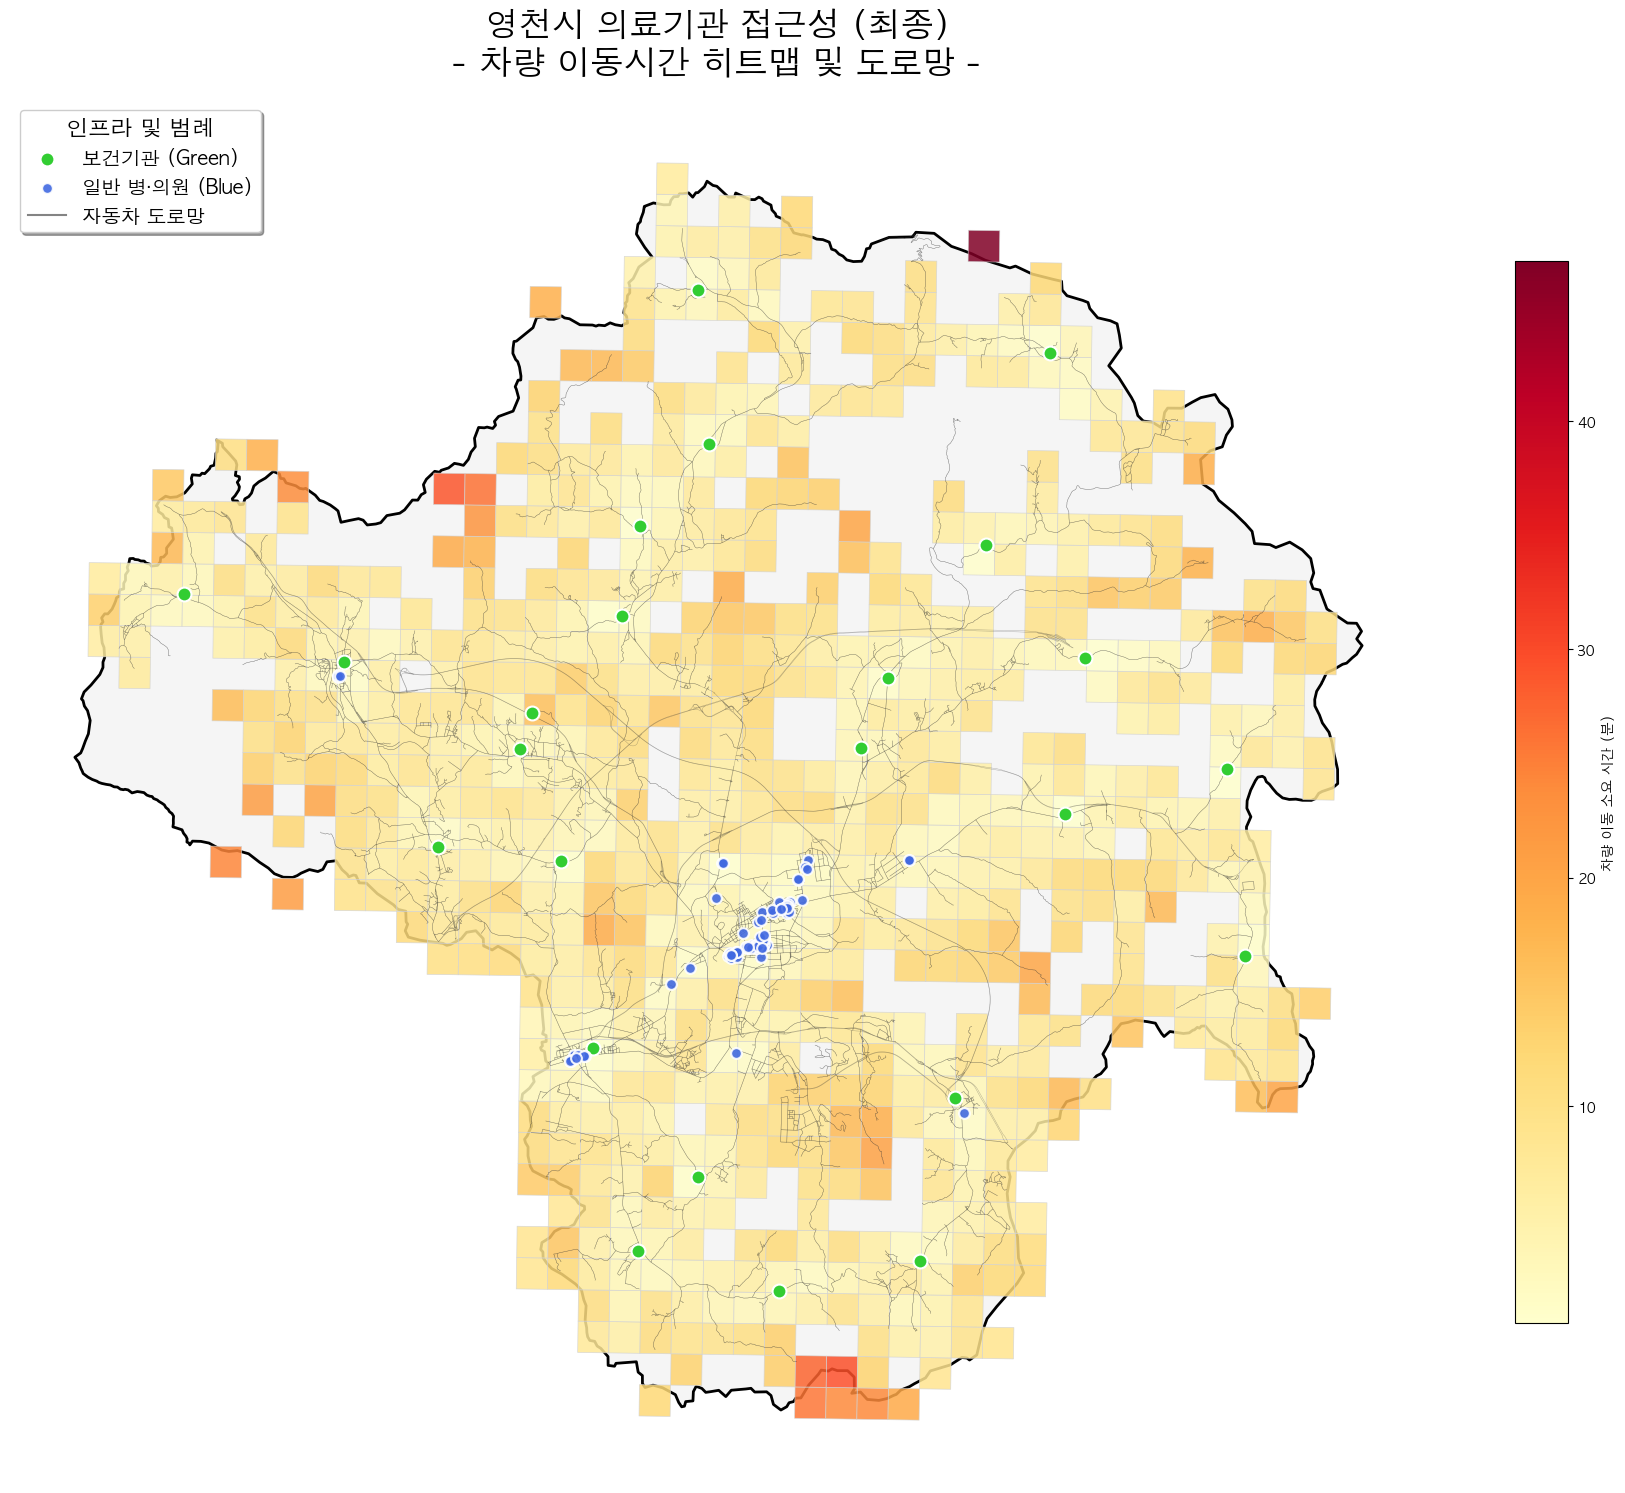

✅ 최종 시각화가 완료되었습니다!


In [65]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import platform
import warnings
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# ==========================================
# 1. 환경 및 폰트 설정
# ==========================================
system_os = platform.system()
if system_os == 'Darwin': plt.rcParams['font.family'] = 'AppleGothic'
elif system_os == 'Windows': plt.rcParams['font.family'] = 'Malgun Gothic'
else: plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. 파일 경로 설정 (방금 저장한 최종본 파일명 적용)
# ==========================================
RESULT_FILE = "step5_final_smoothed_result.csv"  # 평활화(이상치 처리)가 완료된 최종 파일
SHP_FILE = "grid_마마_1K.shp"
MED_CSV_FILE = "경상북도 영천시_의료기관 현황(공공데이터포털,26).csv"
HEALTH_CSV_FILE = "경상북도 영천시_보건지소및보건진료소현황(공공데이터포털,24).csv"

def visualize_final_heatmap():
    print("1️⃣ [데이터 로드] 평활화된 최종 결과 및 공간 데이터를 불러옵니다...")
    
    try:
        df_res = pd.read_csv(RESULT_FILE)
    except FileNotFoundError:
        print(f"❌ '{RESULT_FILE}' 파일을 찾을 수 없습니다. 직전 단계의 파일명을 확인해 주세요.")
        return

    try:
        grid_gdf = gpd.read_file(SHP_FILE).to_crs("EPSG:4326")
        grid_gdf['GRID_CD'] = grid_gdf[grid_gdf.columns[0]].astype(str).str.strip()
    except Exception as e:
        print(f"❌ SHP 파일 로드 오류: {e}")
        return
        
    merged_gdf = grid_gdf.merge(df_res, left_on='GRID_CD', right_on='격자코드', how='inner')

    def load_safe(p):
        try: return pd.read_csv(p, encoding='utf-8')
        except: return pd.read_csv(p, encoding='cp949')

    df_med = load_safe(MED_CSV_FILE)
    df_health = load_safe(HEALTH_CSV_FILE)

    print("2️⃣ [공간 데이터 구축] 영천시 경계 및 자동차 도로망 다운로드 중... (약 1~2분 소요)")
    try:
        # 영천시 외곽선
        yeongcheon_boundary = ox.geocode_to_gdf('Yeongcheon-si, Gyeongsangbuk-do, South Korea')
        # 영천시 도로망 (드라이브 네트워크)
        G_wgs = ox.graph_from_place('Yeongcheon-si, Gyeongsangbuk-do, South Korea', network_type='drive')
        edges = ox.graph_to_gdfs(G_wgs, nodes=False)
    except Exception as e:
        print(f"❌ 도로망/경계 다운로드 오류: {e}")
        return

    print("3️⃣ [시각화] 무결점 히트맵 및 도로망 오버레이 렌더링 중...")
    fig, ax = plt.subplots(figsize=(18, 18))

    # (1) 배경: 영천시 경계선
    yeongcheon_boundary.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=2, zorder=1)

    # (2) 히트맵 렌더링 (평활화가 잘 되었다면 900분 이상 데이터는 거의 없을 것입니다)
    valid_grids = merged_gdf[merged_gdf['최종_이동시간_분'] < 900]
    failed_grids = merged_gdf[merged_gdf['최종_이동시간_분'] >= 900]

    if not valid_grids.empty:
        valid_grids.plot(
            column='최종_이동시간_분', 
            cmap='YlOrRd', 
            ax=ax, 
            alpha=0.85,
            edgecolor='lightgray', 
            linewidth=0.5,
            legend=True, 
            legend_kwds={'label': '차량 이동 소요 시간 (분)', 'shrink': 0.6, 'orientation': 'vertical'},
            zorder=2
        )

    # (3) 진짜 진입 불가 오지 렌더링 (주변 평활화를 거치고도 남은 극오지)
    if not failed_grids.empty:
        failed_grids.plot(ax=ax, color='dimgray', alpha=0.7, hatch='///', edgecolor='black', zorder=3)

    # (4) 도로망 오버레이 (반투명 어두운 선)
    edges.plot(ax=ax, color='#333333', linewidth=0.3, alpha=0.4, zorder=4)

    # (5) 인프라 마커 표시
    ax.scatter(df_health['경도'], df_health['위도'], c='limegreen', s=100, label='보건기관 (Green)', edgecolors='white', linewidth=1.5, zorder=5)
    ax.scatter(df_med['경도'], df_med['위도'], c='royalblue', s=60, label='일반 병·의원 (Blue)', edgecolors='white', linewidth=1.5, alpha=0.9, zorder=5)

    # (6) 디테일 및 타이틀 설정
    ax.set_axis_off()
    plt.title("영천시 의료기관 접근성 (최종)\n- 차량 이동시간 히트맵 및 도로망 -", fontsize=24, fontweight='bold', pad=20)
    
    # 범례 커스텀
    handles, labels = ax.get_legend_handles_labels()
    road_line = Line2D([0], [0], color='#333333', lw=1.5, alpha=0.6, label='자동차 도로망')
    handles.append(road_line)
    labels.append('자동차 도로망')
    
    if not failed_grids.empty:
        failed_patch = mpatches.Patch(facecolor='dimgray', hatch='///', label='차량 진입 불가 (극오지)', alpha=0.7)
        handles.append(failed_patch)
        labels.append('차량 진입 불가 (극오지)')
        
    ax.legend(handles, labels, loc='upper left', fontsize=14, frameon=True, shadow=True, title="인프라 및 범례", title_fontsize=16)

    plt.tight_layout()
    plt.show()
    print("✅ 최종 시각화가 완료되었습니다!")

# 실행
visualize_final_heatmap()

### ** 47분 걸리는 영천시 밖 격자 1개(거주 5명) 수동으로 제거 후 시각화 **

#### -> 결과물 : step5_final_smoothed_result_fix.csv

1️⃣ [데이터 로드] 평활화된 최종 결과 및 공간 데이터를 불러옵니다...
2️⃣ [공간 데이터 구축] 영천시 경계 및 자동차 도로망 다운로드 중... (약 1~2분 소요)
3️⃣ [시각화] 무결점 히트맵 및 도로망 오버레이 렌더링 중...


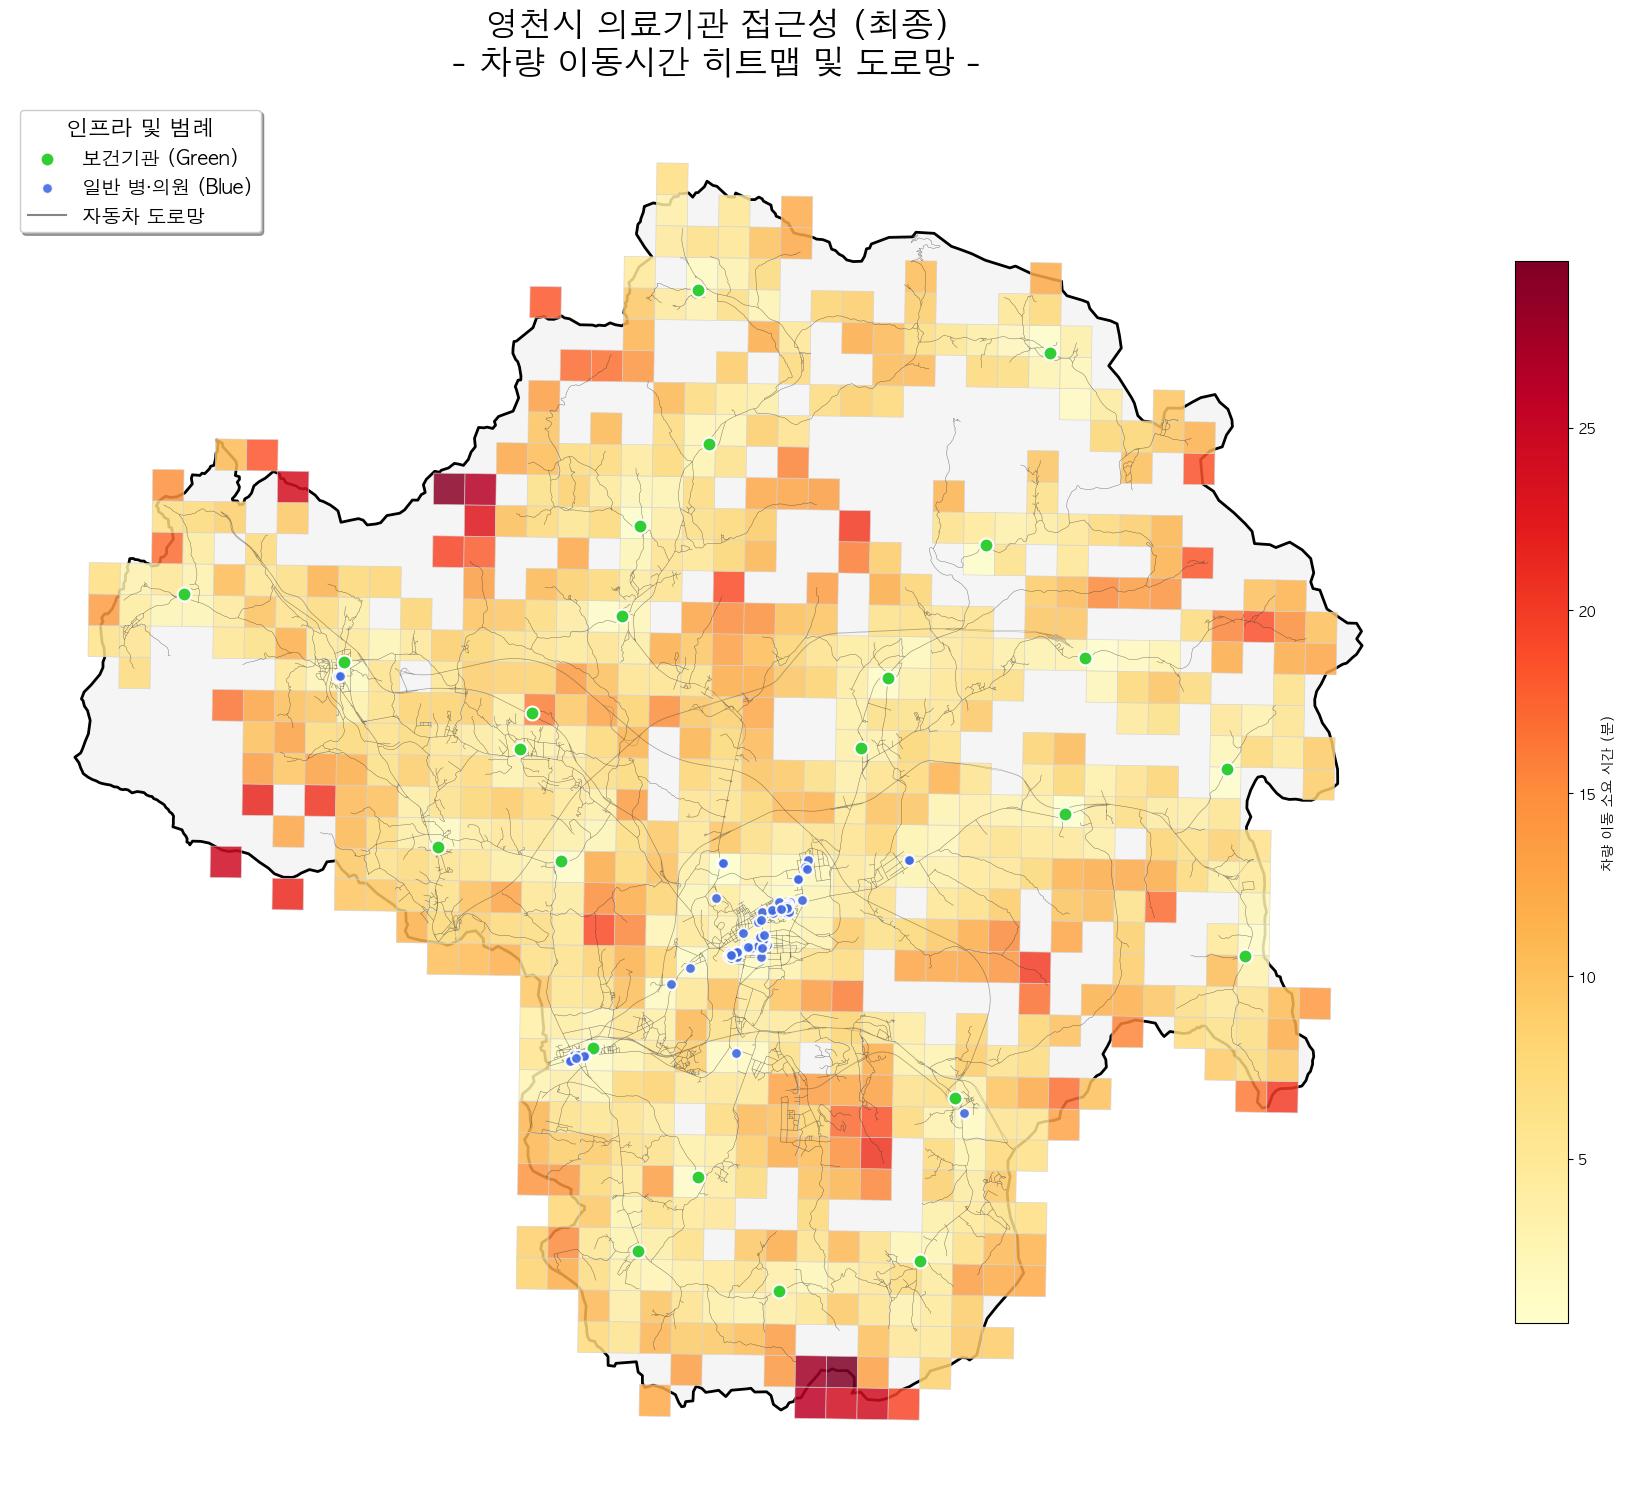

✅ 최종 시각화가 완료되었습니다!


In [66]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import platform
import warnings
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# ==========================================
# 1. 환경 및 폰트 설정
# ==========================================
system_os = platform.system()
if system_os == 'Darwin': plt.rcParams['font.family'] = 'AppleGothic'
elif system_os == 'Windows': plt.rcParams['font.family'] = 'Malgun Gothic'
else: plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. 파일 경로 설정 (방금 저장한 최종본 파일명 적용)
# ==========================================
RESULT_FILE = "step5_final_smoothed_result_fix.csv"  # 평활화(이상치 처리)가 완료된 최종 파일
SHP_FILE = "grid_마마_1K.shp"
MED_CSV_FILE = "경상북도 영천시_의료기관 현황(공공데이터포털,26).csv"
HEALTH_CSV_FILE = "경상북도 영천시_보건지소및보건진료소현황(공공데이터포털,24).csv"

def visualize_final_heatmap():
    print("1️⃣ [데이터 로드] 평활화된 최종 결과 및 공간 데이터를 불러옵니다...")
    
    try:
        df_res = pd.read_csv(RESULT_FILE)
    except FileNotFoundError:
        print(f"❌ '{RESULT_FILE}' 파일을 찾을 수 없습니다. 직전 단계의 파일명을 확인해 주세요.")
        return

    try:
        grid_gdf = gpd.read_file(SHP_FILE).to_crs("EPSG:4326")
        grid_gdf['GRID_CD'] = grid_gdf[grid_gdf.columns[0]].astype(str).str.strip()
    except Exception as e:
        print(f"❌ SHP 파일 로드 오류: {e}")
        return
        
    merged_gdf = grid_gdf.merge(df_res, left_on='GRID_CD', right_on='격자코드', how='inner')

    def load_safe(p):
        try: return pd.read_csv(p, encoding='utf-8')
        except: return pd.read_csv(p, encoding='cp949')

    df_med = load_safe(MED_CSV_FILE)
    df_health = load_safe(HEALTH_CSV_FILE)

    print("2️⃣ [공간 데이터 구축] 영천시 경계 및 자동차 도로망 다운로드 중... (약 1~2분 소요)")
    try:
        # 영천시 외곽선
        yeongcheon_boundary = ox.geocode_to_gdf('Yeongcheon-si, Gyeongsangbuk-do, South Korea')
        # 영천시 도로망 (드라이브 네트워크)
        G_wgs = ox.graph_from_place('Yeongcheon-si, Gyeongsangbuk-do, South Korea', network_type='drive')
        edges = ox.graph_to_gdfs(G_wgs, nodes=False)
    except Exception as e:
        print(f"❌ 도로망/경계 다운로드 오류: {e}")
        return

    print("3️⃣ [시각화] 무결점 히트맵 및 도로망 오버레이 렌더링 중...")
    fig, ax = plt.subplots(figsize=(18, 18))

    # (1) 배경: 영천시 경계선
    yeongcheon_boundary.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=2, zorder=1)

    # (2) 히트맵 렌더링 (평활화가 잘 되었다면 900분 이상 데이터는 거의 없을 것입니다)
    valid_grids = merged_gdf[merged_gdf['최종_이동시간_분'] < 900]
    failed_grids = merged_gdf[merged_gdf['최종_이동시간_분'] >= 900]

    if not valid_grids.empty:
        valid_grids.plot(
            column='최종_이동시간_분', 
            cmap='YlOrRd', 
            ax=ax, 
            alpha=0.85,
            edgecolor='lightgray', 
            linewidth=0.5,
            legend=True, 
            legend_kwds={'label': '차량 이동 소요 시간 (분)', 'shrink': 0.6, 'orientation': 'vertical'},
            zorder=2
        )

    # (3) 진짜 진입 불가 오지 렌더링 (주변 평활화를 거치고도 남은 극오지)
    if not failed_grids.empty:
        failed_grids.plot(ax=ax, color='dimgray', alpha=0.7, hatch='///', edgecolor='black', zorder=3)

    # (4) 도로망 오버레이 (반투명 어두운 선)
    edges.plot(ax=ax, color='#333333', linewidth=0.3, alpha=0.4, zorder=4)

    # (5) 인프라 마커 표시
    ax.scatter(df_health['경도'], df_health['위도'], c='limegreen', s=100, label='보건기관 (Green)', edgecolors='white', linewidth=1.5, zorder=5)
    ax.scatter(df_med['경도'], df_med['위도'], c='royalblue', s=60, label='일반 병·의원 (Blue)', edgecolors='white', linewidth=1.5, alpha=0.9, zorder=5)

    # (6) 디테일 및 타이틀 설정
    ax.set_axis_off()
    plt.title("영천시 의료기관 접근성 (최종)\n- 차량 이동시간 히트맵 및 도로망 -", fontsize=24, fontweight='bold', pad=20)
    
    # 범례 커스텀
    handles, labels = ax.get_legend_handles_labels()
    road_line = Line2D([0], [0], color='#333333', lw=1.5, alpha=0.6, label='자동차 도로망')
    handles.append(road_line)
    labels.append('자동차 도로망')
    
    if not failed_grids.empty:
        failed_patch = mpatches.Patch(facecolor='dimgray', hatch='///', label='차량 진입 불가 (극오지)', alpha=0.7)
        handles.append(failed_patch)
        labels.append('차량 진입 불가 (극오지)')
        
    ax.legend(handles, labels, loc='upper left', fontsize=14, frameon=True, shadow=True, title="인프라 및 범례", title_fontsize=16)

    plt.tight_layout()
    plt.show()
    print("✅ 최종 시각화가 완료되었습니다!")

# 실행
visualize_final_heatmap()

In [68]:
import pandas as pd

def find_suspicious_grids():
    # 파일 경로 설정 (가장 최신 파일)
    input_file = "step5_final_smoothed_result.csv"
    
    try:
        df = pd.read_csv(input_file)
        
        # 보건소/보건진료소 데이터 로드 (보건소가 있는 격자 확인용)
        health_file = "경상북도 영천시_보건지소및보건진료소현황(공공데이터포털,24).csv"
        try:
            df_health = pd.read_csv(health_file, encoding='utf-8')
        except:
            df_health = pd.read_csv(health_file, encoding='cp949')

        print("🚨 [의심 격자 추적 결과]")
        print("=" * 60)

        # ---------------------------------------------------------
        # Case 1: 지도 맨 아래(남쪽)의 시뻘건 격자 추적
        # (위도가 가장 낮으면서 이동 시간이 오래 걸리는 곳)
        # ---------------------------------------------------------
        print("\n📍 1. 지도 하단(남쪽) 극오지 의심 격자")
        print("   (위도 하위 5% 지역 중 이동시간 20분 이상인 곳)")
        
        # 위도 하위 5% 기준값 구하기
        south_lat_threshold = df['위도'].quantile(0.05)
        
        bottom_red_grids = df[(df['위도'] <= south_lat_threshold) & (df['최종_이동시간_분'] >= 20)]
        bottom_red_grids = bottom_red_grids.sort_values(by='위도')
        
        if not bottom_red_grids.empty:
            print(bottom_red_grids[['격자코드', '경도', '위도', '최종_선정_의료기관', '최종_이동시간_분']].to_string(index=False))
        else:
            print("   해당 조건에 맞는 격자가 없습니다.")

        # ---------------------------------------------------------
        # Case 2: 보건소/병원이 코앞인데 시간이 이상하게 높은 곳 추적
        # (주행거리 대비 이동시간이 비정상적인 곳)
        # ---------------------------------------------------------
        print("\n📍 2. 인프라 근접 지역 내 내비게이션 우회 의심 격자")
        print("   (주행거리 2km 이내인데 10분 이상 걸리는 곳)")
        
        # 거리는 짧은데 시간이 오래 걸리는 (속도가 비정상적으로 느린) 격자
        weird_routing_grids = df[(df['최종_주행거리_km'] <= 2.0) & (df['최종_이동시간_분'] >= 10)]
        weird_routing_grids = weird_routing_grids.sort_values(by='최종_이동시간_분', ascending=False)
        
        if not weird_routing_grids.empty:
            print(weird_routing_grids[['격자코드', '경도', '위도', '최종_선정_의료기관', '최종_주행거리_km', '최종_이동시간_분']].to_string(index=False))
        else:
            print("   해당 조건에 맞는 격자가 없습니다.")

        print("=" * 60)
        print("💡 팁: 출력된 '경도, 위도' 값을 카카오맵이나 네이버지도에 입력하면 정확한 위치를 확인할 수 있습니다.")
        
    except FileNotFoundError as e:
        print(f"❌ 파일을 찾을 수 없습니다: {e}")
    except Exception as e:
        print(f"❌ 분석 중 오류 발생: {e}")

# 실행
find_suspicious_grids()

🚨 [의심 격자 추적 결과]

📍 1. 지도 하단(남쪽) 극오지 의심 격자
   (위도 하위 5% 지역 중 이동시간 20분 이상인 곳)
  격자코드         경도        위도 최종_선정_의료기관  최종_이동시간_분
마마3360 128.978051 35.831926    명주보건진료소      23.98
마마3260 128.966983 35.832062    명주보건진료소      23.99
마마3160 128.955914 35.832196    명주보건진료소      25.88
마마3261 128.967149 35.841075    명주보건진료소      29.57
마마3161 128.956079 35.841209    명주보건진료소      27.48

📍 2. 인프라 근접 지역 내 내비게이션 우회 의심 격자
   (주행거리 2km 이내인데 10분 이상 걸리는 곳)
   해당 조건에 맞는 격자가 없습니다.
💡 팁: 출력된 '경도, 위도' 값을 카카오맵이나 네이버지도에 입력하면 정확한 위치를 확인할 수 있습니다.
